<a href="https://colab.research.google.com/github/rana-taqveem/ms-ai-ai-500/blob/main/unsupervised-learning/assignment_2/25280030_PA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI 500 - PA2: Unsupervised Learning**

**Name**: Rana Taqveem Ul Hassan

**Roll Number**: 25280030

---

Before you start the assignment, here's an important clarification: this assignment is divided into two types of graded components—**Tasks** and **Questions**.

-  <span style="color: purple; font-size: 20px;">**Tasks**</span>: involve hands-on programming and require you to implement specific functionalities or solve problems using code.
-  <span style="color: green; font-size: 20px;">**Questions**</span>: are focused on theoretical and analytical interpretation, requiring you to analyze, explain, or draw insights from the tasks you’ve completed. You are **required** to either conduct additional analysis or to reference the coding <span style="color: purple; font-size: 20px;">**Tasks**</span> to supplement your answers to these questions.


Attempting both components is mandatory, as they are designed to complement each other.

**Note:**

- For the cells marked as #DO NOT CHANGE THIS CELL, you are still required to run those cells in order for your PA to be marked as complete. Please be careful about this.

-  When working in Jupyter notebooks, avoid reusing the same variable names across different cells. This can cause overwriting and errors. To avoid this, try using more descriptive variable names to keep track of their purpose and prevent mix-ups.

-  All cells in the notebook must be executed before submission and should display the expected results (graphs, plots, etc.). Any failure to run the cells and display the results will result in point deductions. Please ensure that the notebook is fully functional and the outputs are visible for review.

---

### **MARK SCHEME**


**Coding Tasks (Total 5 tasks, 44 marks)**

- 3 tasks: 10 marks each (30 marks total) – For core implementations.
- Remaining 2 tasks: 7 marks each (14 marks total) – For additional supportive tasks.

**Analytical Questions (Total 14 questions, 56 marks)**

- Main analysis per question: 2 marks (28 marks total) – For the core reasoning and insights.
- Supporting reference (code/math/supplementary per question): 2 marks (28 marks total) – Consistent across all, for evidence-based backing (e.g., code snippets, equations etc).

---

## Submission Instructions

- **Naming Convention**: Name your submission file using the format `RollNumber_PA2.ipynb`.
- **File Submission**: Submit only the `.ipynb` file (Jupyter Notebook) containing your complete code, markdown cells, and outputs. You are not required to submit any prompt logs, but please maintain those on your own end in case of any misunderstanding.
- **Deadline**: Submit your assignment by **11:55 PM PKT on Wednesday, October 15, 2025**. Late submissions will incur a penalty as per the **Late Submission Policy** detailed in the outline.

Good luck, and ensure all tasks are fully implemented and documented!

---

## IMPORTS
-  You are not allowed to change these
-  You cannot import any additional libraries

In [124]:
import numpy as np  # For numerical operations and array manipulations
import matplotlib.pyplot as plt  # For plotting and visualization
import pandas as pd # For data handling and CSV file reading
from sklearn.preprocessing import StandardScaler # For feature scaling
from sklearn.metrics import precision_score, recall_score, f1_score, silhouette_score  # For evaluation metrics
from sklearn.decomposition import PCA # For dimensionality reduction (PCA for visualization)
import requests # For downloading images or data from URLs (used in Tasks 1 and 2)
from io import BytesIO # For handling binary data streams (used with requests)
from PIL import Image # For image processing (used in Tasks 1 and 2)
import cv2 # For computer vision tasks
from sklearn.manifold import TSNE # Again useful for NL dimensionality reduction


Import working


## **Part 1:** Image Segmentation with Clustering (- marks)

**Objective:** This task explores the application of unsupervised clustering techniques to partition an image into meaningful regions based on pixel similarities. By implementing algorithms like K-means and K-medoids, you will investigate how to automatically segment visual data, which is crucial for tasks like object recognition and image editing, offering a foundation for understanding pattern recognition in computer vision.

In [126]:
#DO NOT CHANGE THIS CELL

url = "https://media.wired.com/photos/5b7c67dff521ce3ac9ba45e9/16:9/w_2240,h_1260,c_limit/post10%5Bhttps-_goo.gl_maps_g65Rg5BDBsQ2%5D-(1).jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))
img = np.array(img)

img_resized = np.array(Image.fromarray(img).resize((100, 100)))
height, width, _ = img_resized.shape
pixels = img_resized.reshape(-1, 3).astype(float) / 255.0  # normalize

def rgb_to_ycbcr(rgb):
    r, g, b = rgb[:, 0], rgb[:, 1], rgb[:, 2]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    cb = 0.5 * b - 0.1687 * r - 0.3313 * g + 0.5
    cr = 0.5 * r - 0.4187 * g - 0.0813 * b + 0.5
    return np.column_stack((y, cb, cr))

pixels_ycbcr = rgb_to_ycbcr(pixels)

features = pixels_ycbcr

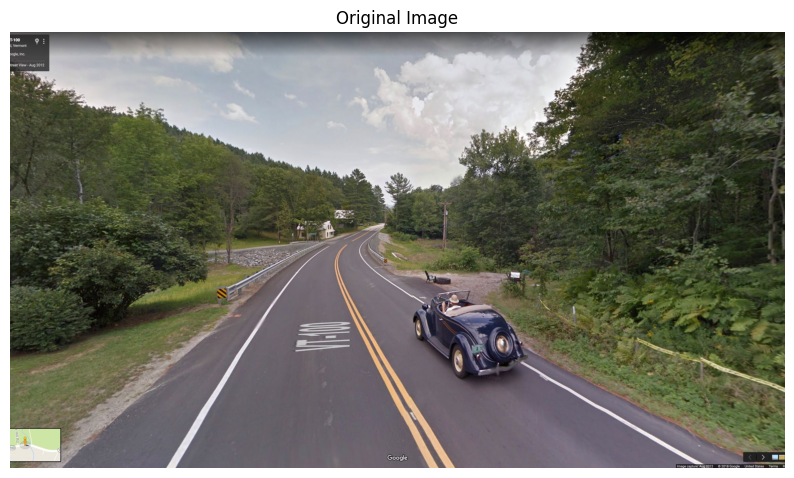

In [127]:
#DO NOT CHANGE THIS CELL

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.show()

<span style="color: purple; font-size: 20px;">**Task 1.1:**</span>

In this task, you will implement clustering algorithms to group data points based on their features. Your goal is to create functions for initializing and performing two popular clustering techniques. Follow these steps to complete the task:

-  Implement a smart **initialization method for K-means clustering** that selects initial centroids to improve convergence.
-  Develop the **K-means algorithm**, allowing for a custom initialization option to enhance clustering efficiency.
-  Create a **K-medoids algorithm**, which uses actual data points as cluster representatives instead of means, focusing on robustness to outliers.
-  Use NumPy for efficient vectorized operations to assign points to clusters and update centroids or medoids.

Hint: Pay attention to the iteration logic and convergence checks in each algorithm. Start by understanding how distances are calculated and minimized to form clusters.

In [128]:
def kmeanspp_init(X, k):
    n = X.shape[0]
    centroids = np.zeros((k, X.shape[1]), dtype=np.float64)
    all_distances = np.full((n, k), np.inf, dtype=np.float64)
    min_distances = np.full(n, np.inf, dtype=np.float64)
    probabilities = np.zeros(n, dtype=np.float64)
    #YOUR CODE HERE

    centroids[0] = X[np.random.randint(n)]
    for counter in range(0, k-1):
        for i, pixel in enumerate(X):
            all_distances[i, counter] = np.sum(np.square(centroids[counter] - pixel))

        min_distances = np.min(all_distances, axis=1)
        total_distance = float(np.sum(min_distances))

        if total_distance == 0:
            probabilities = np.full(n, 1/n)
        else:
            for i, distance in enumerate(min_distances):
                probabilities[i] = distance/total_distance

        centroids[counter+1] = X[np.random.choice(len(min_distances), p=probabilities)]

    return centroids

def kmeanspp_init_opt(X, k):
    n = X.shape[0]
    centroids = np.zeros((k, X.shape[1]), dtype=np.float64)
    all_distances = np.full((n, k), np.inf, dtype=np.float64)
    min_distances = np.full(n, np.inf, dtype=np.float64)
    probabilities = np.zeros(n, dtype=np.float64)

    centroids[0] = X[np.random.randint(n)]
    for counter in range(0, k-1):
        X_L2_norm = np.sum(X**2, axis=1)
        Ci_L2_norm = np.sum(centroids[counter]**2)
        X_dot_Ci = 2 * np.dot(X, centroids[counter])

        all_distances = X_L2_norm + Ci_L2_norm - X_dot_Ci

        min_distances = np.minimum(min_distances, all_distances)
        min_distances = np.clip(min_distances, 0, None)
        total_distance = float(np.sum(min_distances))

        if total_distance == 0:
            probabilities = np.full(n, 1/n)
        else:
            probabilities = np.divide(min_distances, total_distance)

        centroids[counter+1] = X[np.random.choice(len(min_distances), p=probabilities)]

    return centroids

def kmeans(X, k, max_iter=100, init='random'):
    n, d = X.shape
    if init == 'kmeanspp':
        centroids = kmeanspp_init(X, k)
    else:
        centroids = X[np.random.choice(n, k, replace=False)]

    #YOUR CODE HERE

    iteration_num = 0
    while True and iteration_num <= max_iter:

        all_distances = np.full((n, k), np.inf, dtype=np.float64)
        min_distances = np.full(n, np.inf, dtype=np.float64)

        # using loops to compute distance
        for i, centroid in enumerate(centroids):
            for j, pixel in enumerate(X):
                all_distances[j, i] = np.sqrt(np.sum(np.square(centroid - pixel)))

        centroid_indices = np.argmin(all_distances, axis=1)
        uniqure_centiords, inverse_indices = np.unique(centroid_indices, rreturn_inverse=True)
        avg_y_for_centriod = np.bincount(inverse_indices, weights=X[:, 0])/counts
        avg_Cb_for_centriod = np.bincount(inverse_indices, weights=X[:, 1])/counts
        avg_Cr_for_centriod = np.bincount(inverse_indices, weights=X[:, 2])/counts
        new_centroids = np.zeros((k, X.shape[1]), dtype=float)

        for i, new_centroid in enumerate(new_centroids):
            new_centroid[0] = avg_y_for_centriod[i]
            new_centroid[1] = avg_Cb_for_centriod[i]
            new_centroid[2] = avg_Cr_for_centriod[i]

        if np.allclose(centroids, new_centroids):
            break  # Centroids have converged

        centroids = new_centroids.copy()
        iteration_num +=1
    return inverse_indices, centroids

def kmeans_optimized(X, k, max_iter=100, init='random'):
    n, d = X.shape
    if init == 'kmeanspp':
        centroids = kmeanspp_init_opt(X, k)
    else:
        centroids = X[np.random.choice(n, k, replace=False)]

    iteration_num = 0
    while True and iteration_num < max_iter:

        X_L2 = np.sum(X**2, axis=1).reshape(-1, 1)
        Centroid_L2 = np.sum(centroids**2, axis=1).reshape(1, -1)
        X_dot_C =  2 * (X @ centroids.T)
        squared_dis = X_L2 + Centroid_L2 - X_dot_C
        squared_dis = np.maximum(squared_dis,0)
        all_distances = np.sqrt(squared_dis)

        centroid_indices = np.argmin(all_distances, axis=1)
        centroid_wise_clusters = [[] for _ in range(k)]
        for i in range(n):
          centroid_wise_clusters[centroid_indices[i]].append(i)

        new_centroids = np.zeros((k, X.shape[1]), dtype=float)
        for i in range(k):
          cluster = centroid_wise_clusters[i]
          if len(cluster) > 0:
            cluster_points = X[cluster]
            new_centroids[i] = cluster_points.mean(axis=0)
          else:
            new_centroids[i] = centroids[i]

        if np.allclose(centroids, new_centroids):
            break  # Centroids have converged

        centroids = new_centroids.copy()
        iteration_num +=1

    return centroid_indices, centroids

def kmedoids(X, k, max_iter=100):
    n, d = X.shape
    medoids_idx = np.random.choice(n, k, replace=False)
    medoids = X[medoids_idx]

    #YOUR CODE HERE

    expanded = X[:, np.newaxis ]
    pairwise_diff = expanded - X
    pairwise_distances = np.linalg.norm(pairwise_diff, axis =2)

    iteration_num = 0
    while True and iteration_num <= max_iter:

        all_distances = np.full((n, k), np.inf, dtype=np.float64)
        new_mediods_idx = np.zeros(k, np.int64)

        X_L2 = np.sum(X**2, axis=1).reshape(-1,1)
        mediods_L2 = np.sum(medoids**2, axis=1).reshape(1,-1)
        X_dot_C =  2 * (X @ medoids.T)
        all_distances = X_L2 + mediods_L2 - X_dot_C

        centroid_indices = np.argmin(all_distances, axis=1)
        mediod_wise_clusters = [[] for _ in range(k)]
        for i in range(n):
          mediod_wise_clusters[centroid_indices[i]].append(i)

        for i in range(k):
            cluster = mediod_wise_clusters[i]
            if len(cluster) == 0:
              new_mediods_idx[i] = medoids_idx[i]
              continue
            cluster_points = X[cluster]
            cluster_distance = cluster_points[:, np.newaxis] - cluster_points
            pairwise_distances = np.linalg.norm(cluster_distance, axis =2)
            sum_distances = np.sum(pairwise_distances , axis =1)
            best_medoid_idx = np.argmin(sum_distances)
            new_mediods_idx[i] = cluster[best_medoid_idx]

        if np.array_equal(medoids_idx, new_mediods_idx):
            break  # Centroids have converged

        medoids_idx = new_mediods_idx.copy()
        medoids = X[medoids_idx]

        # medoids = new_mediods.copy()
        iteration_num +=1

    return centroid_indices, medoids


def kmedoids_mem_optimized(X, k, max_iter=100):
    n, d = X.shape
    medoids_idx = np.random.choice(n, k, replace=False)
    medoids = X[medoids_idx]

    #YOUR CODE HERE
    iteration_num = 0
    while True and iteration_num <= max_iter:

        all_distances = np.full((n, k), np.inf, dtype=np.float64)
        new_mediods_idx = np.zeros(k, np.int64)

        X_L2 = np.sum(X**2, axis=1).reshape(-1,1)
        mediods_L2 = np.sum(medoids**2, axis=1).reshape(1,-1)
        X_dot_C =  2 * (X @ medoids.T)
        all_distances = X_L2 + mediods_L2 - X_dot_C

        centroid_indices = np.argmin(all_distances, axis=1)
        mediod_wise_clusters = [[] for _ in range(k)]
        for i in range(n):
          mediod_wise_clusters[centroid_indices[i]].append(i)

        for i in range(k):
            cluster = mediod_wise_clusters[i]
            if len(cluster) == 0:
              new_mediods_idx[i] = medoids_idx[i]
              continue
            cluster_points = X[cluster]
            sum_distances = np.zeros(len(cluster))
            for j in range(len(cluster)):
              sum_distances[j] = np.sum(np.sqrt(np.sum((cluster_points - cluster_points[j])**2, axis=1)))
            best_medoid_idx = np.argmin(sum_distances)
            new_mediods_idx[i] = cluster[best_medoid_idx]

        if np.array_equal(medoids_idx, new_mediods_idx):
            break  # Centroids have converged

        medoids_idx = new_mediods_idx.copy()
        medoids = X[medoids_idx]

        # medoids = new_mediods.copy()
        iteration_num +=1

    return centroid_indices, medoids


In [129]:
#DO NOT CHANGE THIS CELL
#We have defined the implementation of the Agglomerative Clustering algorithm for you.

def agglomerative(X, k):
    n = X.shape[0]
    # since n is large, lets sample a subset
    if n > 1000:
        sample_idx = np.random.choice(n, 1000, replace=False)
        X_sample = X[sample_idx]
    else:
        X_sample = X
        sample_idx = np.arange(n)

    m = X_sample.shape[0]
    clusters = list(range(m))
    dist_matrix = np.linalg.norm(X_sample[:, np.newaxis] - X_sample, axis=2)

    while len(set(clusters)) > k:

        # find closest pairs
        min_dist = np.inf
        pair = (-1, -1)
        for i in range(m):
            for j in range(i+1, m):
                if clusters[i] != clusters[j] and dist_matrix[i, j] < min_dist:
                    min_dist = dist_matrix[i, j]
                    pair = (clusters[i], clusters[j])

        # merge
        for i in range(m):
            if clusters[i] == pair[1]:
                clusters[i] = pair[0]

    # map to labels
    unique_clusters = list(set(clusters))
    label_map = {c: i for i, c in enumerate(unique_clusters)}
    sample_labels = np.array([label_map[c] for c in clusters])

    # assign all points to nearest sample cluster centers (approximate)
    centers = np.array([X_sample[sample_labels == i].mean(axis=0) for i in range(k)])
    distances = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
    labels = np.argmin(distances, axis=1)

    return labels

In [130]:


#DO NOT CHANGE THIS CELL (except for the value of k, if you want to)
val_k = 6
X = features
labels_kmeans, centroids_kmeans = kmeans_optimized(features, k=val_k, init='kmeanspp')
labels_kmedoids, medoids = kmedoids(features, k=val_k)
labels_agg = agglomerative(features, k=val_k)

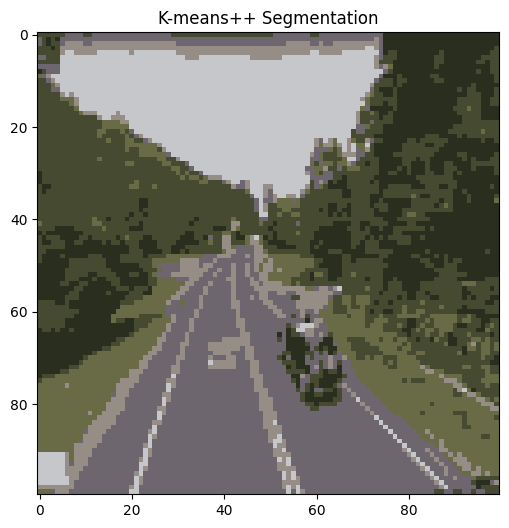

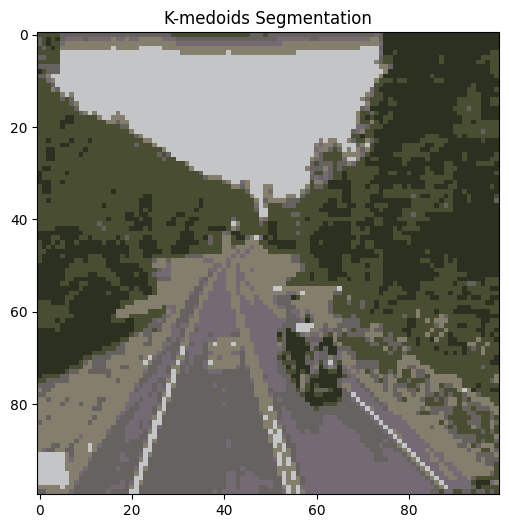

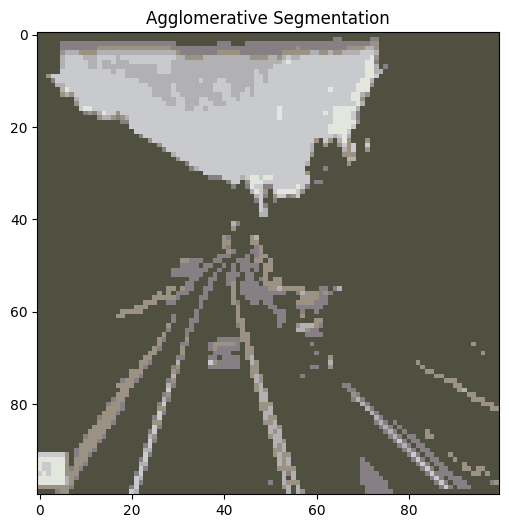

In [131]:
#DO NOT CHANGE THIS CELL
def visualize_segmentation(img, labels, k, title):
    segmented = np.zeros_like(img)
    for i in range(k):
        mask = (labels == i).reshape(img.shape[:2])
        color = img[mask].mean(axis=0)
        segmented[mask] = color.astype(int)
    plt.figure(figsize=(8, 6))
    plt.imshow(segmented)
    plt.title(title)
    plt.show()

visualize_segmentation(img_resized, labels_kmeans, val_k, 'K-means++ Segmentation')
visualize_segmentation(img_resized, labels_kmedoids, val_k, 'K-medoids Segmentation')
visualize_segmentation(img_resized, labels_agg, val_k, 'Agglomerative Segmentation')

<span style="color: purple; font-size: 20px;">**Task 1.2:**</span>

In this task, you will implement a function to evaluate the quality of clustering by calculating the **Within-Cluster Sum of Squares (WCSS)**.  
This metric measures the compactness of clusters. Follow these steps to complete the task:

- Define a function that takes data points (`X`), cluster labels, and cluster centers (centroids or medoids) as inputs.  
- Compute WCSS using the formula:

$$
\text{WCSS} = \sum_{i=1}^{k} \sum_{x \in C_i} \| x - c_i \|^2
$$

where \\( k \\) is the number of clusters, \\( C_i \\) is the set of points in cluster \\( i \\), \\( x \\) is a point, and \\( c_i \\) is the cluster center.  

- Use NumPy to calculate squared Euclidean distances between points and their assigned centers.  
- Handle edge cases, such as empty clusters, by skipping them in the summation.  
- Return the total WCSS score as a float.  

**Hint:** Ensure the shape of inputs aligns correctly.


In [132]:
def calculate_wcss(X, labels, centroids_or_medoids):
    """
    Calculate Within-Cluster Sum of Squares manually.

    Parameters:
    - X: numpy array of shape (n_samples, n_features) containing the data points
    - labels: numpy array of shape (n_samples,) containing cluster labels
    - centroids_or_medoids: numpy array of shape (n_clusters, n_features) containing cluster centers

    Returns:
    - wcss: float, the total WCSS score
    """
    unique_labels = np.unique(labels)
    wcss = 0.0

    # print(f"labels: {labels}")

    # print(f"Number of clusters: {n_clusters}")
    # print(f"Centroids or Medoids shape: {centroids_or_medoids.shape}")
    # print(f"Data points shape: {X.shape}")
    # print(f"Labels shape: {labels.shape}")

    for i, label in enumerate(unique_labels):
      points_in_k = X[labels == label]
      if points_in_k.shape[0] > 0:
        wcss += np.sum((points_in_k - centroids_or_medoids[i])**2)

    print(f"wcss: {wcss}")
    return wcss

wcss: 22.035685285730544
K-means++ Metrics:
  Silhouette Score: 0.5073
  Within-Cluster Sum of Squares (WCSS): 22.0357

wcss: 28.97484283336132
K-medoids Metrics:
  Silhouette Score: 0.3959
  Within-Cluster Sum of Squares (WCSS): 28.9748

wcss: 92.61880277280461
Agglomerative Metrics:
  Silhouette Score: 0.2849
  Within-Cluster Sum of Squares (WCSS): 92.6188



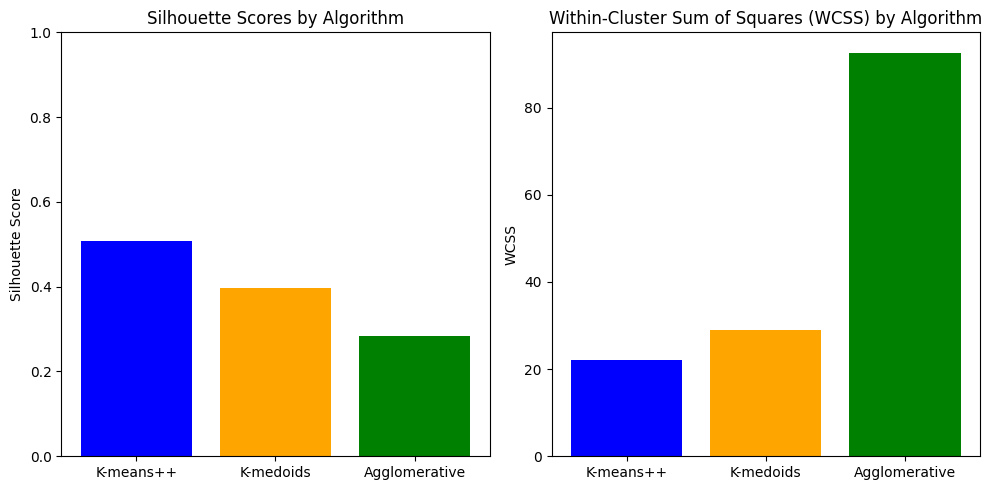

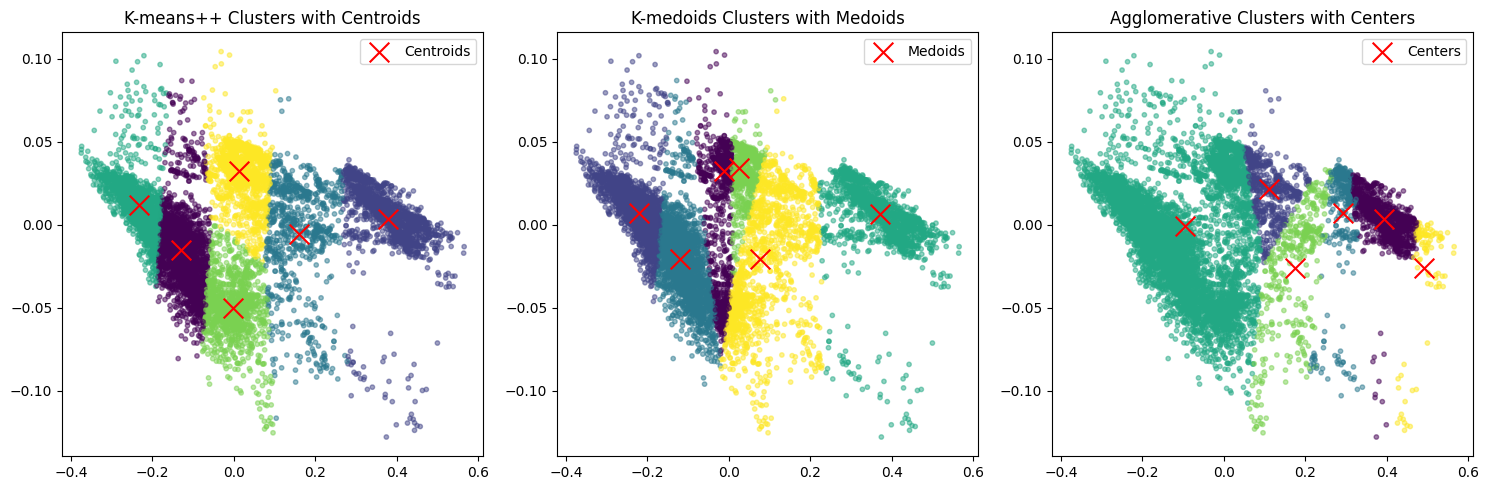

In [133]:
#DO NOT CHANGE THIS CELL

def calculate_metrics(X, labels, centroids_or_medoids=None, algorithm_name=""):
    if len(set(labels)) < 2:
        sil_score = 0
    else:
        sil_score = silhouette_score(X, labels)

    if centroids_or_medoids is not None and len(np.unique(labels)) > 0:
        wcss = calculate_wcss(X, labels, centroids_or_medoids)
    else:
        wcss = 0.0

    print(f"{algorithm_name} Metrics:")
    print(f"  Silhouette Score: {sil_score:.4f}")
    print(f"  Within-Cluster Sum of Squares (WCSS): {wcss:.4f}\n")
    return sil_score, wcss

sil_kmeans, wcss_kmeans = calculate_metrics(features, labels_kmeans, centroids_kmeans, "K-means++")
sil_kmedoids, wcss_kmedoids = calculate_metrics(features, labels_kmedoids, medoids, "K-medoids")
sil_agg, wcss_agg = calculate_metrics(features, labels_agg, np.array([features[labels_agg == i].mean(axis=0) for i in range(val_k) if np.any(labels_agg == i)]), "Agglomerative")

algorithms = ['K-means++', 'K-medoids', 'Agglomerative']
sil_scores = [sil_kmeans, sil_kmedoids, sil_agg]
wcss_values = [wcss_kmeans, wcss_kmedoids, wcss_agg]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(algorithms, sil_scores, color=['blue', 'orange', 'green'])
plt.title('Silhouette Scores by Algorithm')
plt.ylabel('Silhouette Score')
plt.ylim(0, 1)

plt.subplot(1, 2, 2)
plt.bar(algorithms, wcss_values, color=['blue', 'orange', 'green'])
plt.title('Within-Cluster Sum of Squares (WCSS) by Algorithm')
plt.ylabel('WCSS')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

plt.subplot(1, 3, 1)
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.5, s=10)
plt.scatter(pca.transform(centroids_kmeans)[:, 0], pca.transform(centroids_kmeans)[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.title('K-means++ Clusters with Centroids')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_kmedoids, cmap='viridis', alpha=0.5, s=10)
plt.scatter(pca.transform(medoids)[:, 0], pca.transform(medoids)[:, 1], c='red', marker='x', s=200, label='Medoids')
plt.title('K-medoids Clusters with Medoids')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_agg, cmap='viridis', alpha=0.5, s=10)
centroids_agg = np.array([features[labels_agg == i].mean(axis=0) for i in range(val_k) if np.any(labels_agg == i)])
plt.scatter(pca.transform(centroids_agg)[:, 0], pca.transform(centroids_agg)[:, 1], c='red', marker='x', s=200, label='Centers')
plt.title('Agglomerative Clusters with Centers')
plt.legend()

plt.tight_layout()
plt.show()

---
## Analytical Questions

In [134]:
# USE this space and add more cells below this to supplement the answers that you give to the questions that follow
# This is RECOMMENDED. If you feel a question does not require additional analysis, you may refer to the coding tasks above
# Grounding your responses in empirical evidence is standard practice in AI/ML research, so it is important that you support your results with evidence from either:

#       - the coding tasks above
#       - novel analysis conducted below
#       - if questions are of a more foundational nature, then reference the underlying mathematics to back your response.


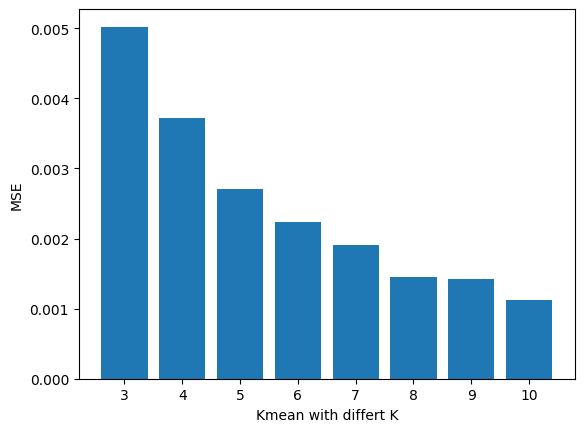

In [135]:
from re import M
# Your code here (optional)
#---

k_sizes = [3, 4, 5, 6, 7, 8, 9, 10]
mse_list = []
for k in k_sizes:
  labels_kmeans, centroids_kmeans = kmeans_optimized(features, k=k, init='kmeanspp')
  mse = np.mean(np.sum((features - centroids_kmeans[labels_kmeans])**2, axis=1))
  mse_list.append(mse)

plt.bar(k_sizes, mse_list)
plt.xlabel('Kmean with differt K')
plt.ylabel('MSE')
plt.show()



<span style="color: green; font-size: 20px;">**Question 1a:**</span> How does varying the number of clusters (k) in K-means++ (e.g., from 3 to 10) affect the segmentation quality, as measured by metrics like mean squared error (MSE) between the original and segmented images? Experiment with at least three different k values and discuss any observed over-segmentation or under-segmentation.

Answer: The MSE computed for the Kmeans++ starting from cluster size 3 until 10 show two distinct patterns:
1. As we increase the number of clusters, the Mean Square Error starts to decrease on each step. It clearly shows that as the number of clusters increases the overall segmentation quality also increases.
2. However, if we analyze the proportional increase in the cluster size and the respective decrease in the MSE, we see that the MSE decreased substantially when the cluster size increased from 3 to 6 however, after that the increase in the cluster size does not reflect a similar effect. The change in MSE starts to become very small on step after step increase in the number of clusters. It shows that up to a certain cluster size we achieved a very good segmentation quality but as we start to further the clustering we are starting to move towards over-segmentation.



<span style="color: green; font-size: 20px;">**Question 1b:**</span> Based on  visualizations that you produce, critique the choice of YCbCr over RGB features—does it enhance color-based segmentation accuracy (e.g., better region boundaries)

Answer: For image processing or segmentation uses case YCbCr is better choice because of the way RGB construct a pixel color. In RGB color we have both the color and its brightness value tied together, for example if you look at the following red color with different brighness levels you can see that RGB values are much different, for dark red its value is much below 200 for red compoenet, where as for a red with normal brightness its red components value is way above 200.
   
   * RGB Red Normal (235, 52, 36)
   * RGB Dark Red   (166, 20, 25)

so if we use RGB for distance calualtions, then the colors with different brightness level might get scattered accross different clusters.

* YCbCr(103, 81, 212) <==> RGB(235, 52, 36)
* YCbCr(71, 109, 192) <==> RGB(166, 25, 25)

In contrast to RGB, YCbCr separate brightness (Y-Channel) from colors making it more appropriate choice for segmentation.

<span style="color: green; font-size: 20px;">**Question 1c:**</span> Explain how the Euclidean distance formula in K-means (minimizing the sum of squared distances from points to centroids) is implemented in the NumPy-based distance calculation step (np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)), and why this vectorized approach improves efficiency over a loop-based method.

Answer: Well, During my first implementation I used  nested loops to first selected the centroid then for each data point in features I computed the Euclidean distance and stored that in a dictionary. This implementation was quite slow.
Then while exploring for optimiztions, from 501 course I remembered that Euclidiean distance = ∣∣xi​−ci​∣∣2= ||x||2 + ||ci||2 - 2.X.Ct.

Therefore, I implemented that. Later in the handout I found that numpy has its direct implementation as well.
So yes computing the distance in loop without using vectors is quite compute intensive and sequential, and use of vectors and matrix operations optimizes the execution speed.

<span style="color: green; font-size: 20px;">**Question 1d:**</span> Based on the computed Silhouette Scores and WCSS values for K-means++, K-medoids, and Agglomerative Clustering, compare how the algorithms perform in terms of cluster separation and compactness—why might one algorithm show higher or lower scores than the others, considering their underlying mechanisms like centroid initialization, medoid selection, or hierarchical merging?

Answer:

* wcss: 22.03568528573054
* K-means++ Metrics:
  Silhouette Score: 0.5073
  Within-Cluster Sum of Squares (WCSS): 22.0357

* wcss: 22.54199940519323
* K-medoids Metrics:
  Silhouette Score: 0.5089
  Within-Cluster Sum of Squares (WCSS): 22.5420

* wcss: 101.2569747641753
* Agglomerative Metrics:
  Silhouette Score: 0.3807
  Within-Cluster Sum of Squares (WCSS): 101.2570

  If we look at the results, we can see that both the K-means++ and K-medoids have very low WCSS numbers as compared to Agglomerative, showing that k-means and k-medoids form compact clusters. Their Silhouette score is also relatively higher than Agglomerative, resulting in good separation as well. Whereas, the Agglomerative struggles with a high WCSS and a low Silhouette score, resulting in less compact clusters. It's because the way Agglomerative forms clusters by combining the closest pair and never revisits to adjust the clusters later, but both k-means++ and K-medoid work iteratively and try to minimize the distance between points and centroids/medoids, resulting in compact and well separated clusters

<span style="color: green; font-size: 20px;">**Question 1e:**</span> Analyze the hierarchical nature of Agglomerative Clustering results: In what ways does it avoid the need for predefined k compared to centroid-based methods, and does this lead to more meaningful regions in the segmented image, or does it introduce biases from the bottom-up merging?

Answer: The Agglomerative clustering works in hierarchial manner. It builds clusters from bottum-up, using a matching a criteria across data points, to merge data points in similar clusters, like a similar linkage based on distance as implemented in this algo. Thats why it does not need a predefined k, and we can stop building the hierarchy tree at any level of tree, as when required.

Well, if we evaluate the clustering results of Agglomerative in this use-case, we can clearly see a resemblance pattern, like a chain connecting similar linkage. The vegetation and road (greens, grey and dark blue) are grouped into 2/3 clusters of green shades whereas the sky (white and light blue) plus white road lines are grouped under shades of white.

Thus it gives a more smoother effect losing subtle shades of green and its shades, and we can clearly see a biasedness among two segments.

---

## **Part 2:** Anomaly Detection in Credit Card Transactions (- marks)

**Objective:** This task delves into detecting unusual patterns in financial data using clustering methods, focusing on identifying fraudulent credit card transactions. By exploring algorithms like K-means++, K-medoids, and DBSCAN, you will address a real-world challenge in cybersecurity and fraud prevention, highlighting the importance of anomaly detection in protecting economic systems.

**Task Preparation:** Before starting the analysis, please download the required dataset from KAGGLE to work with the credit card fraud detection tasks. Follow these steps:

- Visit the following link: [Credit Card Fraud Detection Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).
- Download the `creditcard.csv` file directly, or extract from zipped folder after downloading the dataset.
- Save the file in your working directory to ensure the code can access it, or add to runtime if working with Colab.



In [136]:
# DO NOT CHANGE THIS CELL

In [137]:
#DO NOT CHANGE THIS CELL

df = pd.read_csv('creditcard.csv')

# features: drop Time (not useful), use V1-V28 and Amount
X = df.drop(['Time', 'Class'], axis=1).values
y = df['Class'].values  # y is our target

# preprocessing: standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# subsampling
fraud_idx = np.where(y == 1)[0]
normal_idx = np.random.choice(np.where(y == 0)[0], 5000, replace=False)
sample_idx = np.concatenate((normal_idx, fraud_idx))
X_sample = X_scaled[sample_idx]
y_sample = y[sample_idx]

print(f'Sampled data: {X_sample.shape[0]} points, {np.sum(y_sample)} fraud')

Sampled data: 5371 points, 371.0 fraud


<span style="color: purple; font-size: 20px;">**Task 2.1:**</span> In this task, you are tasked with conducting an exploratory data analysis (EDA) of the Credit Card Fraud dataset. The objective is to gain initial insights into the data through provided analyses, which include summary statistics, distributions, and correlations. You are encouraged to extend this exploration by incorporating your own investigations, such as additional visualizations, feature correlation analyses, or anomaly pattern identification, to deepen your understanding of the dataset.

(190239, 29)


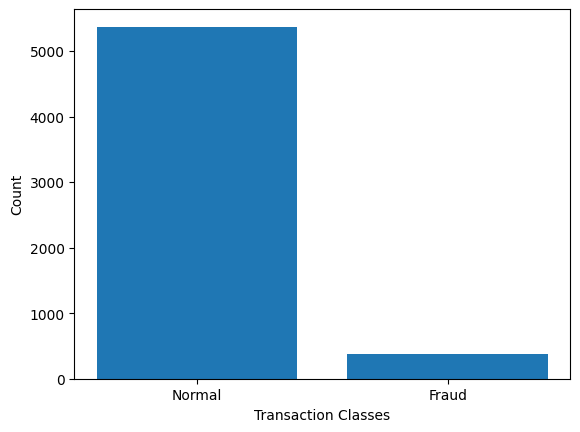

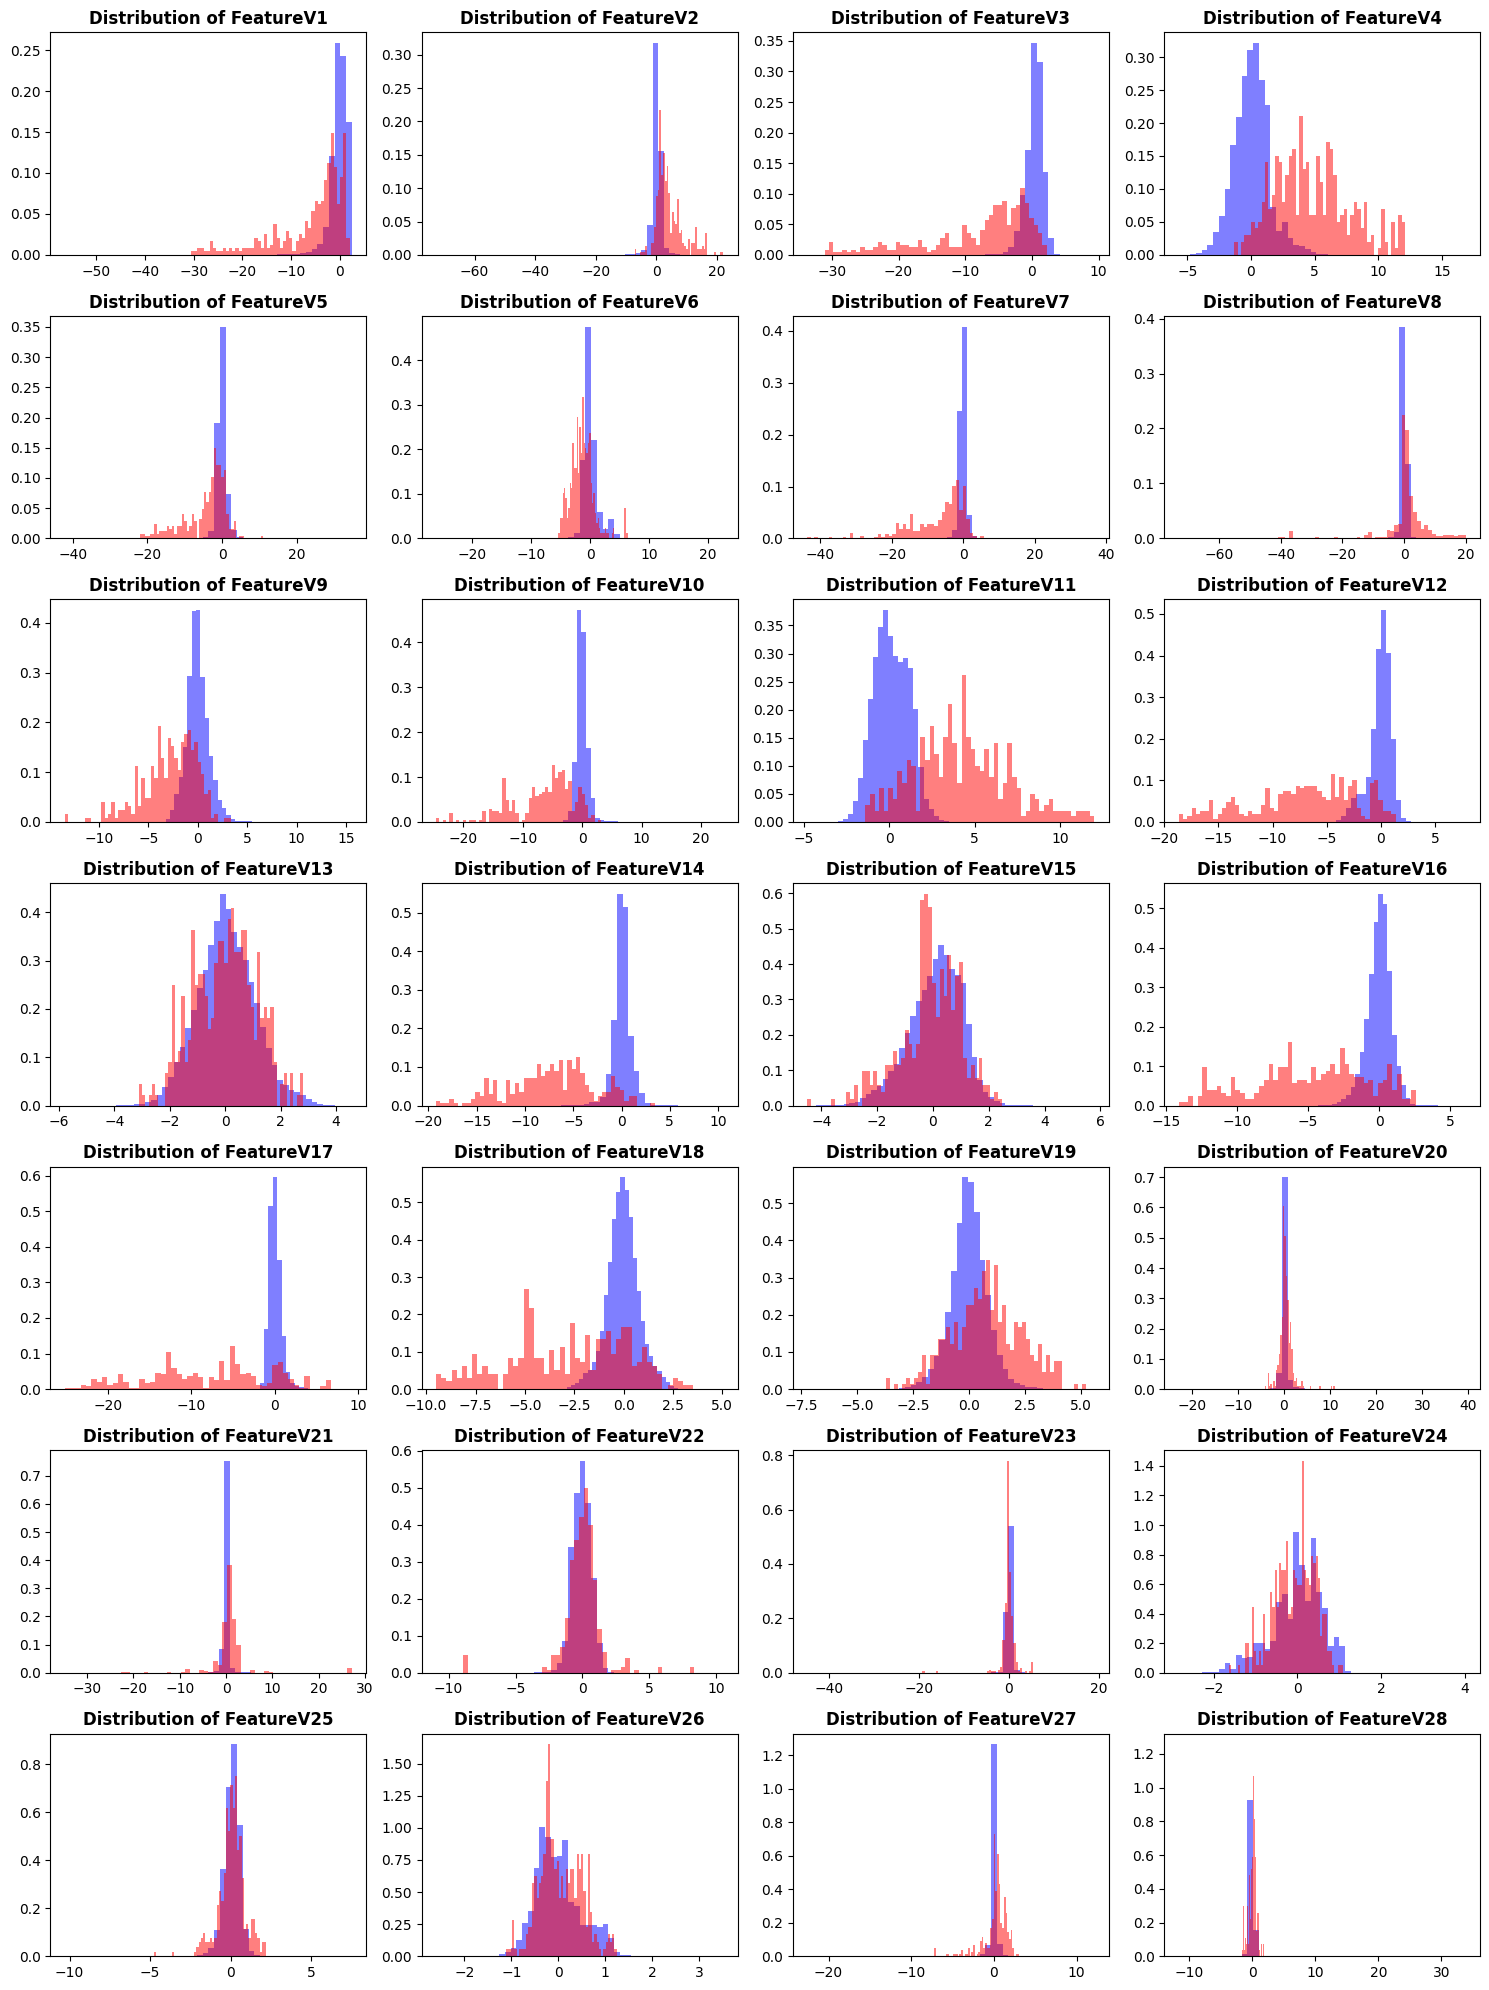

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


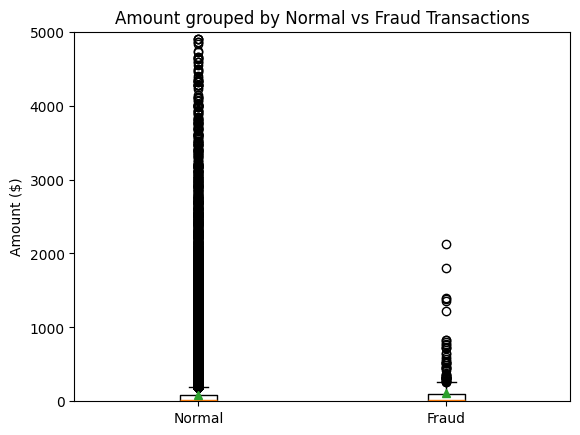

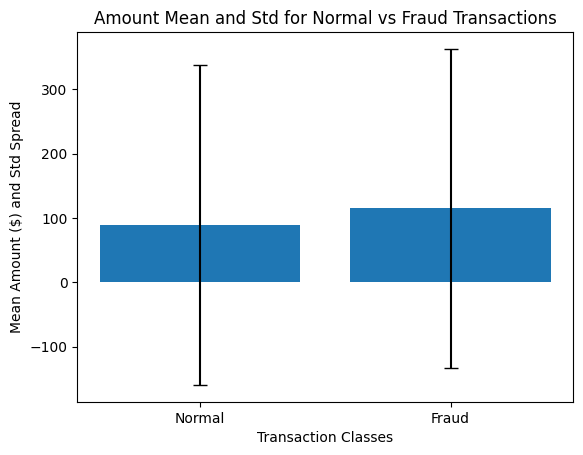

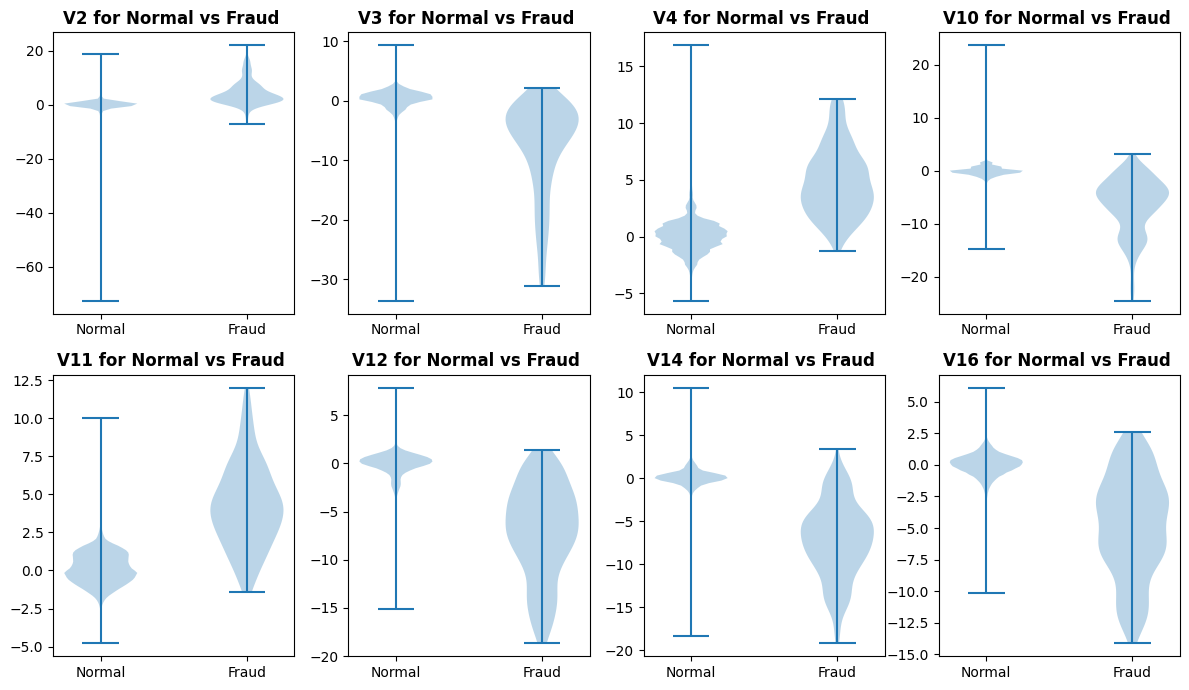

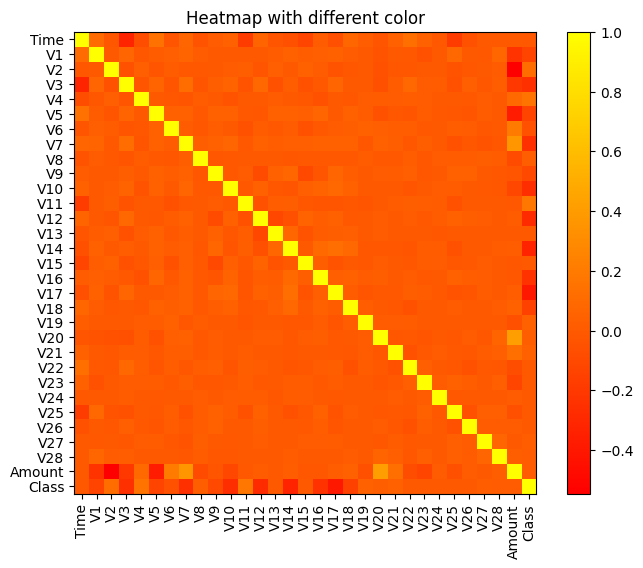

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0.0,189867.0,89.230652,248.469236,0.0,5.99,22.81,79.00,19656.53
1.0,371.0,115.161968,247.521805,0.0,1.00,11.40,102.75,2125.87


In [138]:
#YOUR CODE HERE

def generate_random_rgb_color():
    """Generates a random RGB color as a tuple (r, g, b)."""
    return tuple(np.random.rand(3))

# Example usage:
random_color = generate_random_rgb_color()

print(X.shape)
transaction_classes = ['Normal', 'Fraud']

# counts
data = [X_sample.shape[0], np.sum(y_sample)]
plt.bar(transaction_classes, data)
plt.xlabel('Transaction Classes')
plt.ylabel('Count')
plt.show()

fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(15,20))


columns = ['V'+str(i) for i in range(1,29)]

for column, ax in zip(columns, axes.flatten()):
  data_normal = df[df['Class'] == 0][column].values
  num_bins = 50
  n, bins, _ = ax.hist(data_normal, num_bins, density=True, color='blue', alpha=0.5)
  ax.set_label('Normal')
  ax.set_title(f"Distribution of Feature{column}", fontweight='bold')

  data_fraud = df[df['Class'] == 1][column].values
  num_bins = 50
  n, bins, _ = ax.hist(data_fraud, num_bins, density=True, color='red', alpha=0.5)
  ax.set_label('Fraud')
  ax.set_title(f"Distribution of Feature{column}", fontweight='bold')

plt.tight_layout()
plt.show()

print(columns)

# Transaction Amount
normal_ammounts = df[df['Class'] == 0]['Amount']
fraud_ammounts = df[df['Class'] == 1]['Amount']
data = [normal_ammounts, fraud_ammounts]
plt.boxplot(data, showmeans=True)
plt.ylim(0,5000)
plt.xticks([1, 2], transaction_classes)
plt.ylabel('Amount ($)')

plt.title('Amount grouped by Normal vs Fraud Transactions')
plt.show()

# mean
means = df.groupby('Class')['Amount'].mean()
std = df.groupby('Class')['Amount'].std()
plt.bar(transaction_classes, means.values, yerr=std.values, capsize=5)
plt.ylabel('Mean Amount ($) and Std Spread')
plt.xlabel('Transaction Classes')
plt.title('Amount Mean and Std for Normal vs Fraud Transactions')
plt.show()
# group by class
df.groupby('Class')['Amount'].describe()

features_of_interest = ['V2', 'V3', 'V4', 'V10', 'V11', 'V12', 'V14', 'V16']

fig1, axes1 = plt.subplots(nrows=2, ncols=4, figsize=(12,7))

for foi, ax in zip(features_of_interest, axes1.flatten()):
  normal = df[df['Class'] == 0][foi].dropna()
  fraud = df[df['Class'] == 1][foi].dropna()
  data = [normal, fraud]
  ax.set_xticks([1, 2], transaction_classes)
  ax.violinplot(data)
  ax.set_label('Sensitivity Range')
  ax.set_title(f"{foi} for Normal vs Fraud ", fontweight='bold')
plt.tight_layout()
plt.show()

correlation_matrix = df.corr()
columns = correlation_matrix.columns
plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap='autumn', interpolation='nearest')

# Add colorbar
plt.colorbar()

plt.xticks(range(len(columns)), columns, rotation=90)
plt.yticks(range(len(columns)), columns)
plt.title("Heatmap with different color")
plt.show()

#  df.groupby('Class')['V5'].describe()
df.groupby('Class')['Amount'].describe()




Add the relevant functions in the cell below, you may use your implementations from **Part 1**

In [139]:
# From Task 1 (copy the functions from the previous part)
def kmeanspp_init_wrapper(X, k):
    return kmeanspp_init(X, k)

def kmeans_wrapper(X, k, max_iter=100, init='kmeanspp'):
    return kmeans_optimized(X, k, max_iter, init)

def kmedoids_wrapper(X, k, max_iter=100):
    return kmedoids_mem_optimized(X, k, max_iter)


<span style="color: purple; font-size: 20px;">**Task 2.2:**</span> In this task, you will implement a density-based clustering algorithm to identify clusters and noise in a dataset. Your goal is to develop a function that groups points based on their density. Follow these steps to complete the task:

- Implement the DBSCAN algorithm, which relies on the concept of density-reachable points within a specified radius (eps).  
- Define a `region_query` function to calculate the Euclidean distance \\( \| x_i - x_j \| \\) between a point and all others, returning points within the eps radius.  
- Create an `expand_cluster` function to grow clusters by checking if a point has at least `min_samples` neighbors, using the density-connectivity rule \\( \text{number of points} \geq \min_samples \\).  
- Assign labels where -1 indicates noise, and increment cluster IDs for core points with sufficient neighbors.  


Hint: Focus on the iterative expansion process and how density thresholds determine cluster boundaries.

In [140]:
def dbscan(X, eps, min_samples):
    n = X.shape[0]
    labels = np.full(n, -1)  # -1: noise
    # print(labels.shape)
    cluster_id = 0

    # print(f"Shape of data: {X.shape}")

    def region_query(point_idx):
      point_diffs = X - X[point_idx]
      distances_from_point = np.linalg.norm(point_diffs, axis=1)
      return np.where(distances_from_point <= eps)[0]

    def expand_cluster(point_idx, neighbors):

      nonlocal cluster_id
      neighbors_to_explore = neighbors.copy()
      labels[point_idx] = cluster_id

      while len(neighbors_to_explore) > 0:
          neighbor_idx = neighbors_to_explore[0]
          neighbors_to_explore = neighbors_to_explore[1:]
          if labels[neighbor_idx] == -1:
            labels[neighbor_idx] = cluster_id
            new_neighbors = region_query(neighbor_idx)

            if len(new_neighbors) >= min_samples:
              new_neighbors = new_neighbors[labels[new_neighbors] == -1]
              neighbors_to_explore = np.unique(np.concatenate([neighbors_to_explore, new_neighbors]))

      cluster_id +=1

    for point_idx in range(n):
      if labels[point_idx] != -1:
        continue
      neighbors = region_query(point_idx)
      if len(neighbors) >= min_samples:
        expand_cluster(point_idx, neighbors)

    return labels



In [141]:
#DO NOT CHANGE THIS CELL (Unless you want to experiment with hyperparamters)


# --------------K-means++ applied---------------
labels_kmeans, _ = kmeans_wrapper(X_sample, k=2)
cluster_sizes = np.bincount(labels_kmeans) # map anomaly cluster: we assume here that the smaller cluster is fraud (anomaly)
anomaly_cluster_kmeans = np.argmin(cluster_sizes)
pred_kmeans = (labels_kmeans == anomaly_cluster_kmeans).astype(int)

# # -----------K-medoids applied--------------
labels_kmedoids, _ = kmedoids_wrapper(X_sample, k=2)
cluster_sizes = np.bincount(labels_kmedoids)
anomaly_cluster_kmedoids = np.argmin(cluster_sizes)
pred_kmedoids = (labels_kmedoids == anomaly_cluster_kmedoids).astype(int)

# -----------DBSCAN applied(tune eps and min_samples for the dataset)---------------

labels_dbscan = dbscan(X_sample, eps=3.0, min_samples=15)  # adjust based on data scale
# noise (-1) as anomalies (fraud)
pred_dbscan = (labels_dbscan == -1).astype(int)

Visualize Clusters (PCA + t-SNE for 2D Projection)

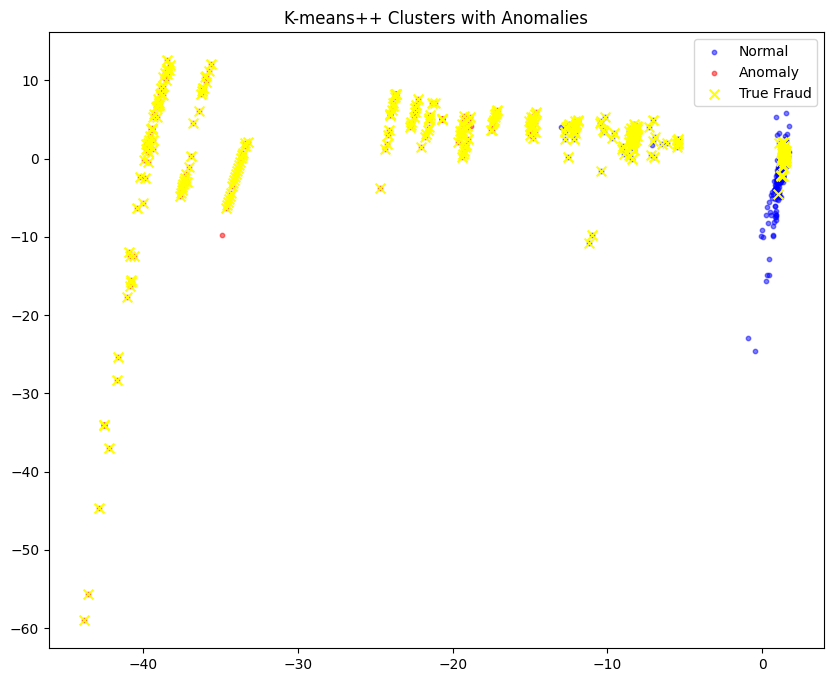

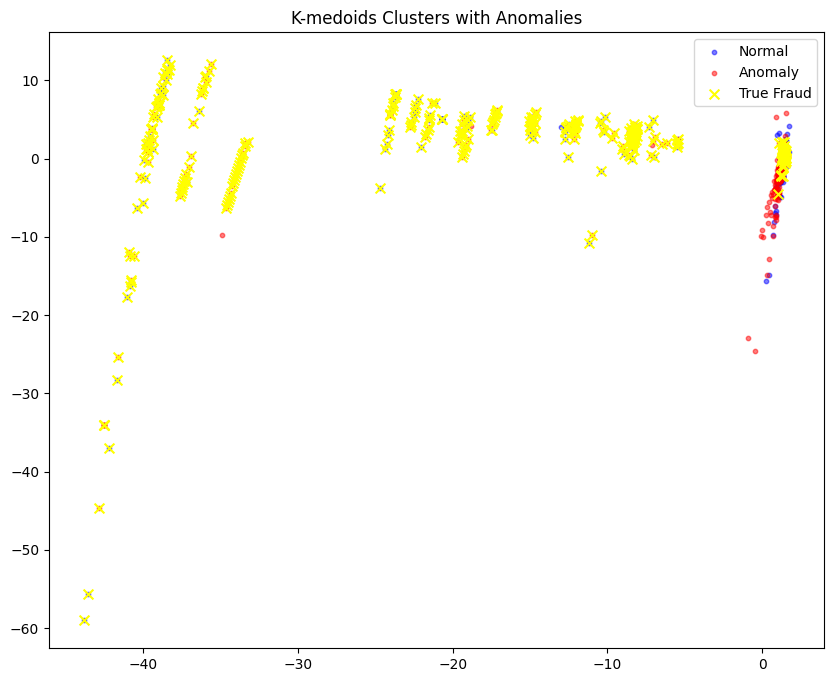

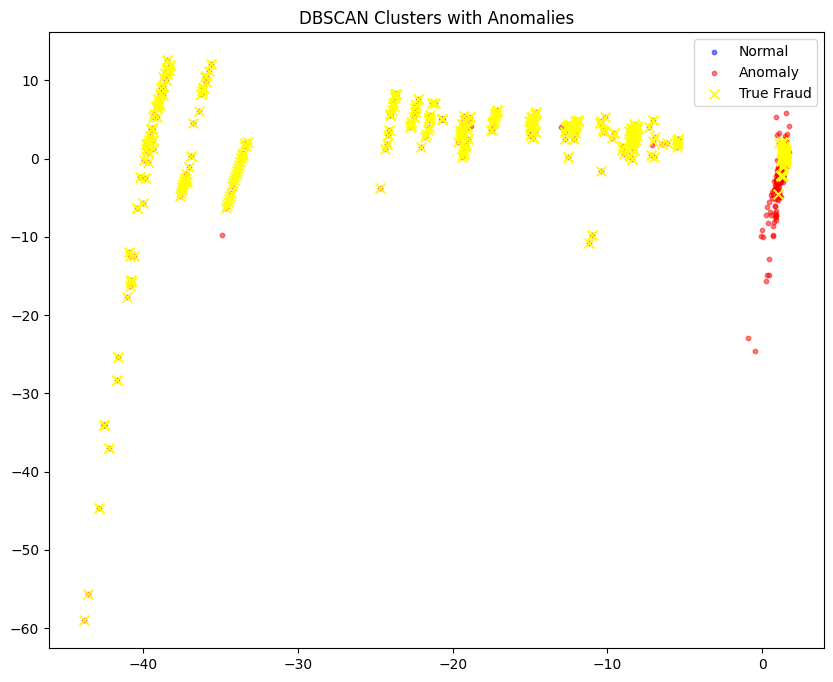

In [142]:
#DO NOT CHANGE THIS CELL

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

def plot_clusters_enhanced(X_pca, labels, y_true, title):
    plt.figure(figsize=(10, 8))

    if -1 in labels:
        anomaly_mask = (labels == -1)
    else:
        anomaly_mask = (labels == np.argmin(np.bincount(labels[labels >= 0])))
    plt.scatter(X_pca[~anomaly_mask, 0], X_pca[~anomaly_mask, 1], c='blue', label='Normal', alpha=0.5, s=10)
    plt.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1], c='red', marker = 'o',label='Anomaly', alpha=0.5, s=10)

    plt.scatter(X_pca[y_true == 1, 0], X_pca[y_true == 1, 1], c='yellow',marker = 'x', label='True Fraud', s=50)
    plt.title(title)
    plt.legend()
    plt.show()

plot_clusters_enhanced(X_pca, labels_kmeans, y_sample, 'K-means++ Clusters with Anomalies')
plot_clusters_enhanced(X_pca, labels_kmedoids, y_sample, 'K-medoids Clusters with Anomalies')
plot_clusters_enhanced(X_pca, labels_dbscan, y_sample, 'DBSCAN Clusters with Anomalies')

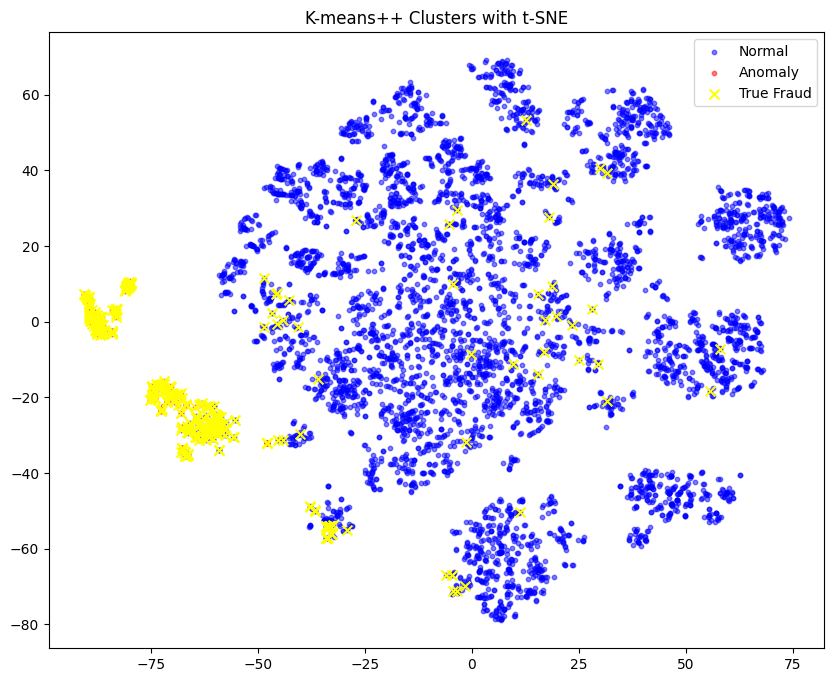

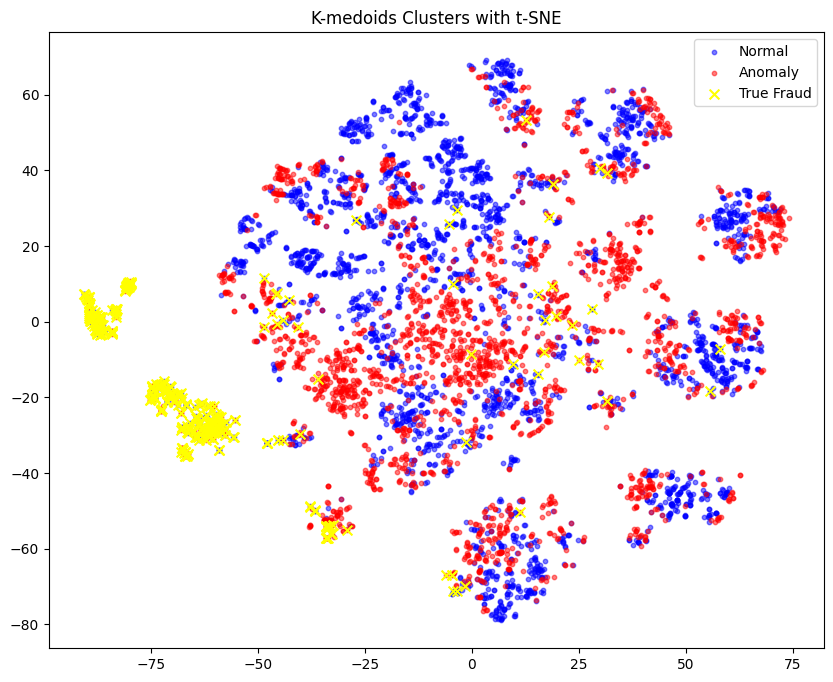

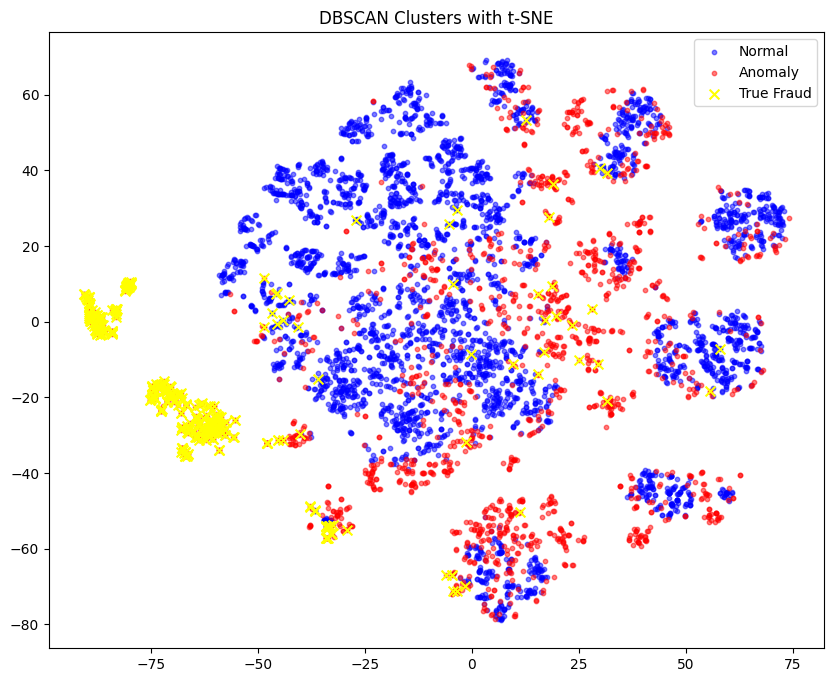

In [143]:
#DO NOT CHANGE THIS CELL

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

def plot_clusters_tsne(X_tsne, labels, y_true, title):
    plt.figure(figsize=(10, 8))

    if np.any(labels < 0):
        anomaly_mask = (labels == -1)
    else:
        anomaly_mask = (labels == np.argmin(np.bincount(labels + (labels < 0).astype(int))))

    plt.scatter(X_tsne[~anomaly_mask, 0], X_tsne[~anomaly_mask, 1], c='blue', label='Normal', alpha=0.5, s=10)

    plt.scatter(X_tsne[anomaly_mask, 0], X_tsne[anomaly_mask, 1], c='red', marker = 'o', label='Anomaly', alpha=0.5, s=10)

    plt.scatter(X_tsne[y_true == 1, 0], X_tsne[y_true == 1, 1], c='yellow', marker = 'x', label='True Fraud', s=50)
    plt.title(title)
    plt.legend()
    plt.show()


plot_clusters_tsne(X_tsne, labels_kmeans, y_sample, 'K-means++ Clusters with t-SNE')
plot_clusters_tsne(X_tsne, labels_kmedoids, y_sample, 'K-medoids Clusters with t-SNE')
plot_clusters_tsne(X_tsne, labels_dbscan, y_sample, 'DBSCAN Clusters with t-SNE')

In [144]:
#DO NOT CHANGE THIS CELL

def evaluate(pred, y_true, algo_name):
    sil = silhouette_score(X_sample, pred) if len(set(pred)) > 1 else 0
    prec = precision_score(y_true, pred)
    rec = recall_score(y_true, pred)
    f1 = f1_score(y_true, pred)
    print(f'{algo_name}:')
    print(f'  Silhouette Score: {sil:.4f}')
    print(f'  Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}\n')
    return sil, prec, rec, f1

metrics = {}
metrics['K-means++'] = evaluate(pred_kmeans, y_sample, 'K-means++')
metrics['K-medoids'] = evaluate(pred_kmedoids, y_sample, 'K-medoids')
metrics['DBSCAN'] = evaluate(pred_dbscan, y_sample, 'DBSCAN')

print('Note:')
print('- Silhouette: Higher is better for clustering cohesion/separation.')
print('- Precision/Recall/F1: Higher is better for anomaly (fraud) detection.')

K-means++:
  Silhouette Score: 0.7805
  Precision: 0.9899, Recall: 0.5283, F1: 0.6889

K-medoids:
  Silhouette Score: 0.0311
  Precision: 0.0791, Recall: 0.5391, F1: 0.1380

DBSCAN:
  Silhouette Score: 0.2467
  Precision: 0.1967, Recall: 0.9353, F1: 0.3251

Note:
- Silhouette: Higher is better for clustering cohesion/separation.
- Precision/Recall/F1: Higher is better for anomaly (fraud) detection.


---
## Analytical Questions

In [145]:
# USE this space and add more cells below this to supplement the answers that you give to the questions that follow
# This is RECOMMENDED. If you feel a question does not require additional analysis, you may refer to the coding tasks above
# Grounding your responses in empirical evidence is standard practice in AI/ML research, so it is important that you support your results with evidence from either:

#       - the coding tasks above
#       - novel analysis conducted below
#       - if questions are of a more foundational nature, then reference the underlying mathematics to back your response.


In [146]:
print("----------- K-means++ Fraud Detection ---------")
k_sizes = [2, 3, 4, 5]
for k_size in k_sizes:
  labels_kmeans2, _ = kmeans_optimized(X_sample, k=k_size)
  cluster_sizes2 = np.bincount(labels_kmeans2) # map anomaly cluster: we assume here that the smaller cluster is fraud (anomaly)
  anomaly_cluster_kmeans2 = np.argmin(cluster_sizes2)
  pred_kmeans2 = (labels_kmeans2 == anomaly_cluster_kmeans2).astype(int)
  evaluate(pred_kmeans2, y_sample, 'K-means++')

----------- K-means++ Fraud Detection ---------
K-means++:
  Silhouette Score: 0.7805
  Precision: 0.9899, Recall: 0.5283, F1: 0.6889

K-means++:
  Silhouette Score: 0.7805
  Precision: 0.9899, Recall: 0.5283, F1: 0.6889

K-means++:
  Silhouette Score: 0.7892
  Precision: 0.9888, Recall: 0.4771, F1: 0.6436

K-means++:
  Silhouette Score: 0.4123
  Precision: 0.0707, Recall: 0.0189, F1: 0.0298



In [147]:

print("----------- DB Scan Fraud Detection ---------")
eps_sizes = [2.0,3.0,4.0]
samples = [5,10,15]

data = []
for eps in eps_sizes:
  for min_sample in samples:

    print(f"EPS: {eps}")
    print(f"min_sample: {min_sample}")
    labels_dbscan = dbscan(X_sample, eps=eps, min_samples=min_sample)  # adjust based on data scale
    pred_dbscan = (labels_dbscan == -1).astype(int)
    sil, prec, rec, f1 = evaluate(pred_dbscan, y_sample, 'DBSCAN')

----------- DB Scan Fraud Detection ---------
EPS: 2.0
min_sample: 5
DBSCAN:
  Silhouette Score: 0.0015
  Precision: 0.1030, Recall: 0.8868, F1: 0.1845

EPS: 2.0
min_sample: 10
DBSCAN:
  Silhouette Score: -0.0716
  Precision: 0.1000, Recall: 0.9946, F1: 0.1818

EPS: 2.0
min_sample: 15
DBSCAN:
  Silhouette Score: -0.1235
  Precision: 0.0910, Recall: 0.9973, F1: 0.1667

EPS: 3.0
min_sample: 5
DBSCAN:
  Silhouette Score: 0.2928
  Precision: 0.2138, Recall: 0.7925, F1: 0.3368

EPS: 3.0
min_sample: 10
DBSCAN:
  Silhouette Score: 0.2774
  Precision: 0.2116, Recall: 0.9245, F1: 0.3444

EPS: 3.0
min_sample: 15
DBSCAN:
  Silhouette Score: 0.2467
  Precision: 0.1967, Recall: 0.9353, F1: 0.3251

EPS: 4.0
min_sample: 5
DBSCAN:
  Silhouette Score: 0.5083
  Precision: 0.3783, Recall: 0.6658, F1: 0.4824

EPS: 4.0
min_sample: 10
DBSCAN:
  Silhouette Score: 0.5272
  Precision: 0.3979, Recall: 0.8194, F1: 0.5357

EPS: 4.0
min_sample: 15
DBSCAN:
  Silhouette Score: 0.5145
  Precision: 0.4027, Recall: 0.8

In [148]:

# Your code here (optional)
# ---
print("----------- K-medoid Fraud Detection ---------")
k_sizes = [2, 3, 4, 5]
for k_size in k_sizes:
  print(f"k: {k_size}")
  labels_kmedoids, _ = kmedoids_wrapper(X_sample, k=k_size)
  cluster_sizes = np.bincount(labels_kmedoids)
  anomaly_cluster_kmedoids = np.argmin(cluster_sizes)
  pred_kmedoids = (labels_kmedoids == anomaly_cluster_kmedoids).astype(int)
  evaluate(pred_kmedoids, y_sample, 'K-medoids')


----------- K-medoid Fraud Detection ---------
k: 2
K-medoids:
  Silhouette Score: 0.0146
  Precision: 0.0500, Recall: 0.3235, F1: 0.0866

k: 3
K-medoids:
  Silhouette Score: 0.0773
  Precision: 0.0783, Recall: 0.2426, F1: 0.1184

k: 4
K-medoids:
  Silhouette Score: -0.0623
  Precision: 0.0045, Recall: 0.0081, F1: 0.0058

k: 5
K-medoids:
  Silhouette Score: 0.2045
  Precision: 0.0992, Recall: 0.0970, F1: 0.0981



<span style="color: green; font-size: 20px;">**Question 2a:**</span> Examine how increasing the number of clusters (k from 2 to 5) in K-means++ influences fraud detection metrics (precision, recall, F1), particularly in identifying the anomaly cluster as the smallest one, and discuss any dilution of recall with higher k.

Answer: As per our sampled dataset, approximately 10% of transactions are fraud transactions, and more than 90% are normal transactions. Since K-means clusters data based on distance, it has no idea about the data ratio between normal and fraudulent transactions. So with k-2, it clusters data only into 2 groups, thus the majority of frauds are correctly grouped into one cluster and normal transactions into the other clusters, resulting in a better recall.

However, when the k is increased, the cluster sizes are reduced, resulting in the fraud transactions being distributed in multiple clusters. The cluster we are labeling as fraud starts to receive fewer fraud transactions, thus reducing the correct number of true fraud predictions vs the actual number of frauds.

Precision with either low or high k size does not reflect much change because most of the predicted frauds are actually frauds, and there are fewer false positives, resulting in a significantly higher precision for all ks.

Finally, F1 is majorly reflecting the change in recall, as recall decreases, F1 decreases


<span style="color: green; font-size: 20px;">**Question 2b:**</span> For DBSCAN, test variations in eps (e.g., 2.0 to 4.0) and min_samples (e.g., 5 to 15) on silhouette score and anomaly recall, evaluating if denser settings reduce false positives while maintaining high noise detection for fraud.

Answer: I analyzed the DBScan from eps (2.0,3.0,4.0) and each with min_samples of 5,10,15. The results of metrics show that with eps of 2.0, the scan resulted in a high recall, meaning that a good number of data points got labeled as anomalies whereas the precision is very low, meaning that there are many false positives. As we increase the 3.0, there is a good improvement from 0.12 -> 0.25 in precision, meaning fewer false positives, but recall is still high around 0.9x -> 0.83. However, with eps 4.0 the precision increased to 0.45 the more correct true positive and lesser false positives.
The silhouette score also shows the effect of increasing eps from 2.0 to 4.0, resulting in better cluster formations and improved separation among them.
This shows that with denser settings, large eps and high min_samples improved the cluster quality and also reduced the false alarms and also managed to capture substantial fraud transactions



<span style="color: green; font-size: 20px;">**Question 2c:**</span> Illustrate how DBSCAN's density-based expansion (core points with min_samples neighbors within eps) is implemented in the expand_cluster function using recursive neighbor queries, and contrast this with the mathematical definition of density-reachable points.

Answer: Once a core point, let call it ‘Q’ is identified (a point which has enough neighbors as per the min samples within the eps) we build a list of immediate neighbors of the core point.
Then the Expand Cluster function is used to find the neighbors of neighbors of the core point Q. During this expansion, we start by exploring each immediate neighbor of the Q, while exploring the neighbor we look for the data points within the defined eps radius of the current neighbor, and add any those points into the list of immediate neighbors of the core point Q. Why Q be we reached here from the Q and we are looking for the neighbor of neighbor Q, like build a conencted chain. The process is repeated for all the neighbors of the core point, neighbor after neighbor, until for each neighbor there are no longer data points within the eps.
Here, for optimization we only add neighbors to the immediate neighbors list the core point Q, which are not already explored so that we do not visit them again and again.
A Density reachability is defined as ' A point ‘Q’ is density reachable from point ‘P’, if we can travel from P to Q through a path of core points' each within the eps of the next point'. As we can see that during the Expand Cluster function we are actually reaching to a point P through the neighbors of Q, thus exactly depicting the principle of Density Reachable points.



<span style="color: green; font-size: 20px;">**Question 2d:**</span> Based on the comparative metrics, evaluate K-medoids' performance w.r.t your other algorithms? Any particular reason to justify its relative performance?

Answer:
k: 2
K-medoids:
  Silhouette Score: 0.0399
  Precision: 0.0894, Recall: 0.4085, F1: 0.1467

k: 3
K-medoids:
  Silhouette Score: 0.0326
  Precision: 0.0658, Recall: 0.1850, F1: 0.0971

k: 4
K-medoids:
  Silhouette Score: 0.4831
  Precision: 0.2222, Recall: 0.0203, F1: 0.0372

k: 5
K-medoids:
  Silhouette Score: 0.7359
  Precision: 1.0000, Recall: 0.5589, F1: 0.7171


For K-mediod the results are up and down may be sometime for some ks its was able to perform pretty good like its has shown high precision and upto 0.56 of recall mean it caught 56% fraud transactions however on another run with the same k its resulted in poor performance like precision reducing to 0.3, recall to 0.02, perhaps because of the randon k initialization. So, comparing with k-means++, which perform ok with lower k and DBScan with high eps, k-mediod is sensitive to the data point selected as medoid and the chosen k.


---

## **Part 3:** Skin Detection via YCbCr + GMM (- marks)

**Objective:** This task investigates skin detection in images using the Gaussian Mixture Model (GMM) in the YCbCr color space, exploring how to model complex skin tone distributions for applications like face detection. By implementing this from scratch, you will uncover the power of probabilistic modeling in image processing, essential for tasks in biometrics and human-computer interaction.

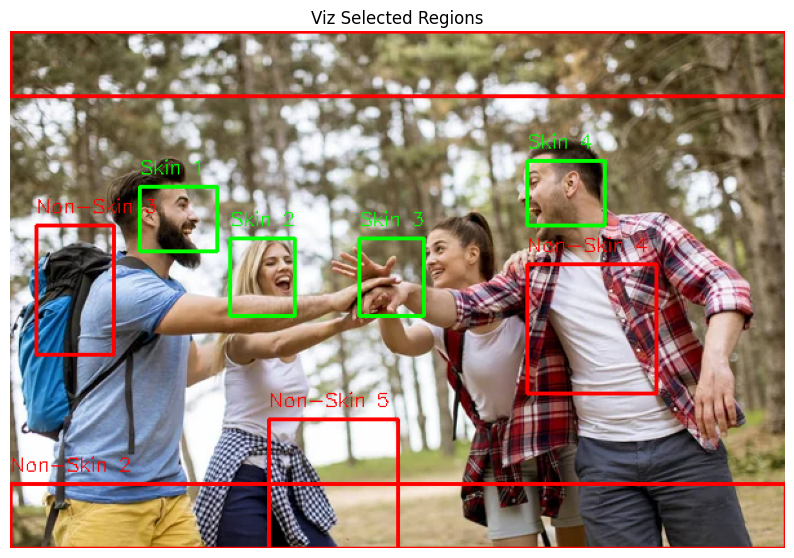

In [149]:
#DO NOT CHANGE THIS CELL


url = 'https://st4.depositphotos.com/1022135/27218/i/450/depositphotos_272186204-stock-photo-group-young-people-hiking-mountain.jpg'

response = requests.get(url)
img_skin = Image.open(BytesIO(response.content))
img_skin = np.array(img_skin)

def rgb_to_ycbcr(rgb):
    r, g, b = rgb[:, 0], rgb[:, 1], rgb[:, 2]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    cb = 0.5 * b - 0.1687 * r - 0.3313 * g + 0.5
    cr = 0.5 * r - 0.4187 * g - 0.0813 * b + 0.5
    return np.column_stack((y, cb, cr))

pixels_skin = img_skin.reshape(-1, 3).astype(float) / 255.0
ycbcr_skin = rgb_to_ycbcr(pixels_skin)

# Get dimensions
h, w = img_skin.shape[:2]

skin_patches = [
    (120, 170, 100, 160),   # (start_row, end_row, start_col, end_col)
    (160, 220, 170, 220),
    (160, 220, 270, 320),
    (100, 150, 400, 460)
]
skin_indices = []
for sr, er, sc, ec in skin_patches:
    for row in range(sr, er):
        for col in range(sc, ec):
            skin_indices.append(row * w + col)
skin_region = ycbcr_skin[skin_indices]


non_skin_patches = [
    (0, 50, 0, w),         # Top
    (h-50, h, 0, w),       # Bottom
    (150, 250, 20, 80),   # Backpack
    (180, 280, 400, 500),    # Right trees
    (300, 400, 200, 300)   # Ground
]
non_skin_indices = []
for sr, er, sc, ec in non_skin_patches:
    for row in range(sr, er):
        for col in range(sc, ec):
            non_skin_indices.append(row * w + col)
non_skin_region = ycbcr_skin[non_skin_indices]

# Use CbCr channels
skin_cbcr = skin_region[:, 1:]
non_skin_cbcr = non_skin_region[:, 1:]
test_cbcr = ycbcr_skin[:, 1:]

img_with_regions = cv2.cvtColor(img_skin, cv2.COLOR_RGB2BGR)

for i, (sr, er, sc, ec) in enumerate(skin_patches):
    cv2.rectangle(img_with_regions, (sc, sr), (ec, er), (0, 255, 0), 2)  # green box
    cv2.putText(img_with_regions, f'Skin {i+1}', (sc, sr - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

for i, (sr, er, sc, ec) in enumerate(non_skin_patches):
    cv2.rectangle(img_with_regions, (sc, sr), (ec, er), (0, 0, 255), 2)  # red box
    cv2.putText(img_with_regions, f'Non-Skin {i+1}', (sc, sr - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_regions, cv2.COLOR_BGR2RGB))
plt.title('Viz Selected Regions')
plt.axis('off')
plt.show()

<span style="color: purple; font-size: 20px;">**Task 3.1:**</span>  
In this task, you will implement a Gaussian Mixture Model (GMM) using the Expectation-Maximization (EM) algorithm to model complex data distributions. Your goal is to develop functions that estimate the parameters of multiple Gaussian components. Follow these steps to complete the task:

- Implement the `gaussian_pdf` function to compute the probability density function of a Gaussian distribution, using the formula:  
  - \\( P(x) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu)\right) \\)  
  - Where \\( d \\) is the dimensionality, \\( \mu \\) is the mean, \\( \Sigma \\) is the covariance matrix, and use NumPy for matrix operations (e.g., inverse, determinant, and exponential).  

- Create the `gmm_em` function to iteratively fit the GMM:  
  - **E-step**: Calculate responsibilities (posterior probabilities) for each data point to belong to each Gaussian using the PDF and current parameters.  
  - **M-step**: Update the weights, means, and covariances based on the responsibilities, ensuring numerical stability with regularization (e.g., small diagonal addition to covariances).  
  - Use a log-likelihood convergence check to stop iterations, with a tolerance and maximum iteration limit.  

- Initialize parameters randomly (e.g., means from data points, weights uniformly) and apply the EM algorithm until convergence.  


**Hints**: Start by coding the Gaussian PDF with matrix operations for efficiency. For EM, implement the E-step by normalizing probabilities across components, and in the M-step, use weighted averages for updates. Add a small regularization term to avoid singular covariance matrices. Debug with a small dataset to verify convergence.


In [180]:

def gaussian_pdf(X, mean, cov):
    d = X.shape[1]

    # #  compute inverse of covariance matrix
    # regularization = np.eye( d ) * 1e-6
    # cov_reg = cov + regularization

    #  compute inverse of regularized covariance matrix
    # cov_inverse = np.linalg.inv(cov_reg)

    cov_inverse = np.linalg.inv(cov)

    #  compute how far and in what direction data points lie by
    # compute the difference between the data points and their mean

    x_u = X- mean
    temp = x_u @ cov_inverse
    squared_term = temp * x_u
    sum = np.sum( squared_term , axis =1)
    exp_result = np.exp(-0.5 * sum )


    #  calculate the normalization value to normalize the probability distribution
    # covariance_det = np.linalg.det(cov_reg)
    covariance_det = np.linalg.det(cov)
    two_pi_d_half = np.power(2 * np.pi, -d / 2.0)
    inv_det_half = np.power(covariance_det, -0.5)
    normalize_c = two_pi_d_half * inv_det_half

    pdf = normalize_c * exp_result
    return pdf


def gmm_em(X, k, max_iter=50, tol=1e-4):
    n, d = X.shape
    weights = np.ones(k) / k
    means = X[np.random.choice(n, k, replace=False)]
    covs = [np.cov(X.T) + np.eye(d) * 1e-6 for _ in range(k)]

    likelihoods = np.zeros((n, k))
    responsibility_of_x = np.zeros((n, k))

    iteration_num = 0
    old_log_likelihood = -np.inf
    log_lik_old = -np.inf
    while True and iteration_num <= max_iter:
        # E-step
        for i in range(k):
            pdf = gaussian_pdf(X, means[i], covs[i])
            likelihoods[:, i] = weights[i] * pdf

        # print(f"Likelihoods shape: {likelihoods.shape}")

        weighted_likelihood_P = np.sum(likelihoods, axis=1)
        # print(f"Weighted Likelihood P shape: {weighted_likelihood_P.shape}")
        # print(f"Weighted Likelihood P:  {weighted_likelihood_P}")

        responsibility_of_x = likelihoods / weighted_likelihood_P[:, np.newaxis]
        # print(f"Responsibility shape: {responsibility_of_x.shape}")

        log_likelihood = np.sum(np.log(weighted_likelihood_P))
        # print(f"Log Likelihood: {log_likelihood}")

        # M-step
        # new weights
        nk = np.sum(responsibility_of_x, axis=0)
        # print(f"N_k shape: {nk.shape}")

        new_weights = nk / n
        # print(f"New weights: {new_weights.shape}")

        # new means
        # print(f"Responsibility of x.T shape: {responsibility_of_x.T.shape}")
        # print(f"X shape: {X.shape}")

        temp = (responsibility_of_x.T @ X)
        # print(f"Temp shape: {temp.shape}")

        # print(f"N_k[:, np.newaxis] shape: {nk[:, np.newaxis].shape}")
        new_mean = temp / nk[:, np.newaxis]
        # new_mean = temp / nk[:, np.newaxis]
        # print(f"New mean: {new_mean}")

        # new covariances
        for i in range(k):
            diff = X - new_mean[i].reshape(1, -1)
            # print(f"Diff shape {i}: {diff.shape}")
            # print(f"Responsibility shape {i}: {responsibility_of_x[:, i].shape}")
            # print(f"Responsibility of x[:, i] new shape {i}: {responsibility_of_x[:, i][:, np.newaxis].shape}")

            weighted_diff = responsibility_of_x[:, i][:, np.newaxis] * diff
            # print(f"Weighted diff shape {i}: {weighted_diff.shape}")

            weighted_diif_T = weighted_diff.T
            # print(f"Weighted diff T shape {i}: {weighted_diif_T.shape}")
            # print(f"Diff shape {i}: {diff.shape}")

            product = weighted_diif_T @ diff
            # print(f"Product shape {i}: {product.shape}")
            # print(f"N_k[i] shape {i}: {nk[i].shape}")
            new_cov = product / nk[i]

            # print(f"New cov shape {i}: {new_cov.shape}")

            regularization = np.eye( d ) * 1e-6
            covs[i] = new_cov + regularization

            # print(f"Updated cov shape {i}: {covs[i].shape}")


        weights = new_weights
        means = new_mean


        if np.abs(log_likelihood - old_log_likelihood) < tol:
            break

        old_log_likelihood = log_likelihood
        iteration_num +=1


    return weights, means, covs

In [182]:
#DO NOT CHANGE THIS CELL - (unless you want to play around with the components param)


# Fit GMMs (use 3 components for flexibility)
weights_skin, means_skin, covs_skin = gmm_em(skin_cbcr, 3)
weights_non, means_non, covs_non = gmm_em(non_skin_cbcr, 3)

Classify Pixels

In [183]:
#DO NOT CHANGE THIS CELL (you may experiment with hyperparams here if you want (e.g threshold))

def gmm_likelihood(X, weights, means, covs):
    k = len(weights)
    lik = np.zeros(X.shape[0])
    for i in range(k):
        lik += weights[i] * gaussian_pdf(X, means[i], covs[i])
    return lik

lik_skin = gmm_likelihood(test_cbcr, weights_skin, means_skin, covs_skin)
lik_non = gmm_likelihood(test_cbcr, weights_non, means_non, covs_non)
ratio = lik_skin / (lik_non + 1e-10)
threshold = 5 # Adjust as needed
skin_mask = (ratio > threshold).reshape(img_skin.shape[:2])

Visualize Skin Regions and Candidate Face Bounding Boxes

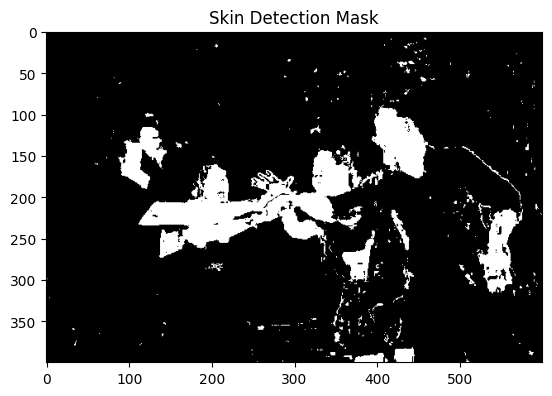

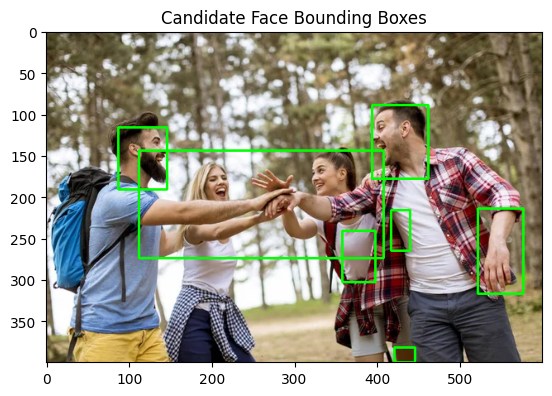

In [185]:
#DO NOT CHANGE THIS CELL

plt.imshow(skin_mask, cmap='gray')
plt.title('Skin Detection Mask')
plt.show()

contours, _ = cv2.findContours(skin_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_with_boxes = cv2.cvtColor(img_skin, cv2.COLOR_RGB2BGR)
for cnt in contours:
    if cv2.contourArea(cnt) > 250:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.title('Candidate Face Bounding Boxes')
plt.show()

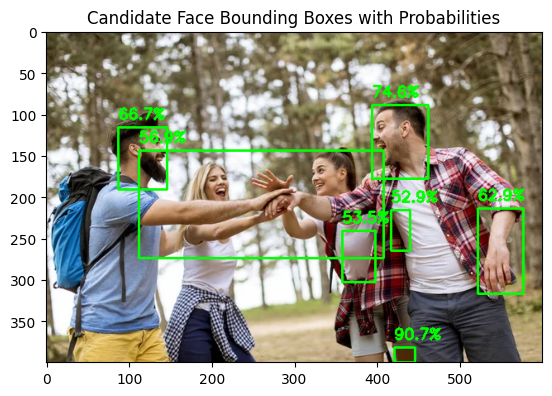

In [186]:
#DO NOT CHANGE THIS CELL - Compute per-pixel probability of skin

prob_skin = lik_skin / (lik_skin + lik_non + 1e-10)
prob_skin = prob_skin.reshape(img_skin.shape[:2])

img_with_boxes = cv2.cvtColor(img_skin, cv2.COLOR_RGB2BGR)
for cnt in contours:
    if cv2.contourArea(cnt) > 250:
        x, y, w, h = cv2.boundingRect(cnt)

        region_prob = prob_skin[y:y+h, x:x+w]
        avg_prob = region_prob.mean()

        cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

        cv2.putText(
            img_with_boxes,
            f"{avg_prob*100:.1f}%",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.title('Candidate Face Bounding Boxes with Probabilities')
plt.show()

---
## Analytical Questions

In [155]:
# Use this space and add more cells below this to supplement the answers that you give to the questions that follow
# This is RECOMMENDED. If you feel a question does not require additional analysis, you may refer to the coding tasks above
# Grounding your responses in empirical evidence is standard practice in AI/ML research, so it is important that you support your results with evidence from either:

#       - the coding tasks above
#       - novel analysis conducted below
#       - if questions are of a more foundational nature, then reference the underlying mathematics to back your response.


componnts: 2, Accuracy: 0.8726734693877551
componnts: 3, Accuracy: 0.8792244897959184
componnts: 4, Accuracy: 0.8180816326530612
componnts: 5, Accuracy: 0.8686428571428572


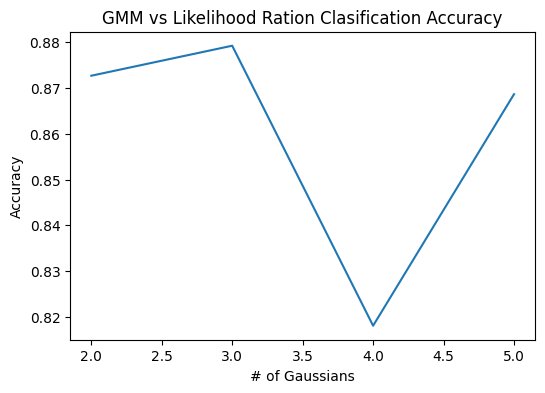

In [156]:
# Your code here (optional)
#---

def calculate_lrc_accuracy():

  accuracies = []
  k_sizes = [2, 3, 4, 5]
  for k in k_sizes:
    weights_skin, means_skin, covs_skin = gmm_em(skin_cbcr, k)
    weights_non, means_non, covs_non = gmm_em(non_skin_cbcr, k)

    lik_skin = gmm_likelihood(test_cbcr, weights_skin, means_skin, covs_skin)
    lik_non = gmm_likelihood(test_cbcr, weights_non, means_non, covs_non)

    ration = lik_skin / (lik_non)
    y_pred = (ration > threshold).astype(int)

    y_true = np.zeros(test_cbcr.shape[0])
    y_true[skin_indices] = 1
    y_true[non_skin_indices] = 0

    labels = skin_indices + non_skin_indices
    y_true_set = y_true[labels]
    y_pred_set = y_pred[labels]

    acc = np.mean(y_pred_set == y_true_set)
    print(f"componnts: {k}, Accuracy: {acc}")
    accuracies.append(acc)


  plt.figure(figsize=(6,4))
  plt.plot(k_sizes, accuracies)
  plt.title('GMM vs Likelihood Ration Clasification Accuracy')
  plt.xlabel('# of Gaussians')
  plt.ylabel('Accuracy')
  plt.show()

calculate_lrc_accuracy()


componnts= 3, tol=0.0001, max_iter=50, Accuracy: 0.8598061224489796, FPR= 0.20568859649122806
componnts= 3, tol=0.0001, max_iter=100, Accuracy: 0.8882142857142857, FPR= 0.17827192982456141
componnts= 3, tol=1e-06, max_iter=50, Accuracy: 0.8669591836734694, FPR= 0.1939298245614035
componnts= 3, tol=1e-06, max_iter=100, Accuracy: 0.8775714285714286, FPR= 0.17276315789473684


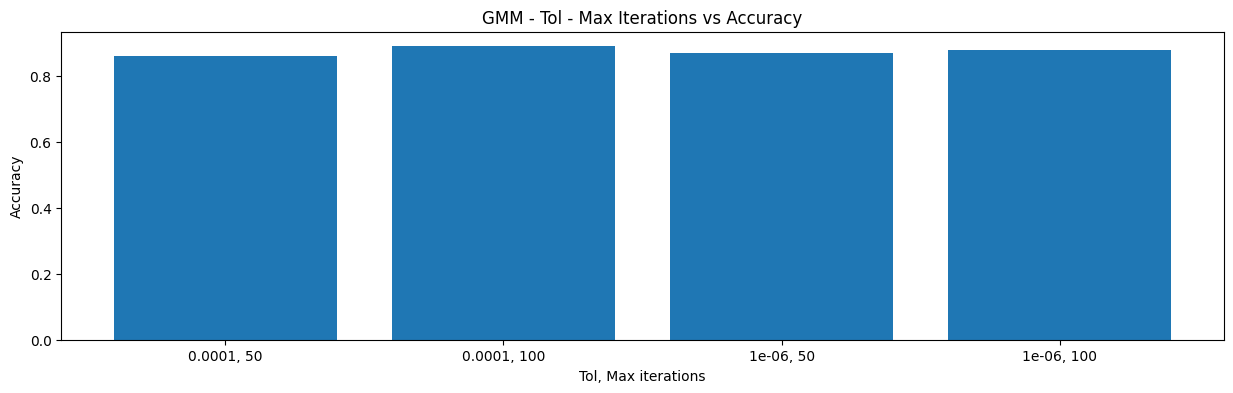

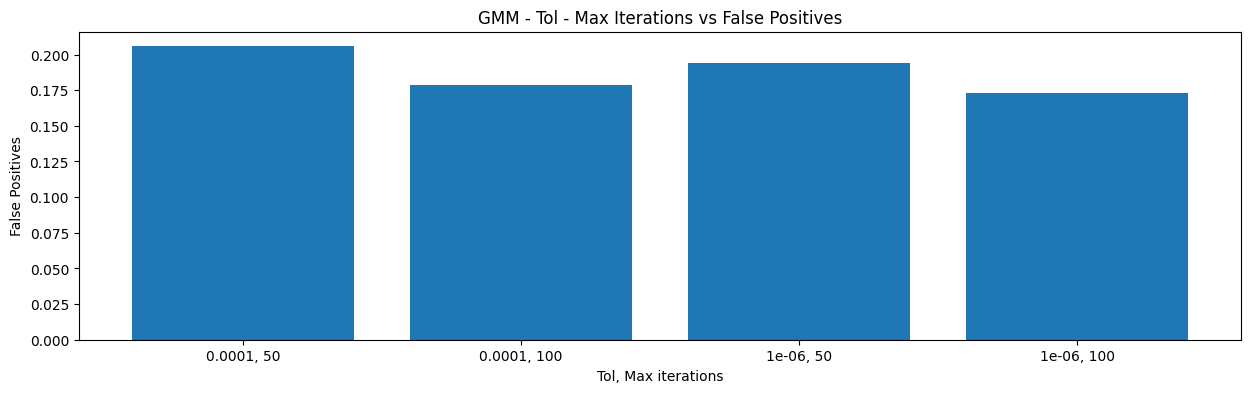

In [157]:

from sklearn.metrics import confusion_matrix

gmm_settings = [
    {"tol": 1e-4, "max_iter": 50},
    {"tol": 1e-4, "max_iter": 100},
    {"tol": 1e-6, "max_iter": 50},
    {"tol": 1e-6, "max_iter": 100}]

accuracies = []
fprs = []

for gs in gmm_settings:
    weights_skin, means_skin, covs_skin = gmm_em(X=skin_cbcr, k=3,  max_iter=gs['max_iter'], tol=gs['tol'])
    weights_non, means_non, covs_non = gmm_em(X=non_skin_cbcr, k=3, max_iter=gs['max_iter'], tol=gs['tol'])

    lik_skin = gmm_likelihood(test_cbcr, weights_skin, means_skin, covs_skin)
    lik_non = gmm_likelihood(test_cbcr, weights_non, means_non, covs_non)

    ration = lik_skin / (lik_non)
    y_pred = (ration > threshold).astype(int)

    y_true = np.zeros(test_cbcr.shape[0])
    y_true[skin_indices] = 1
    y_true[non_skin_indices] = 0

    labels = skin_indices + non_skin_indices
    y_true_set = y_true[labels]
    y_pred_set = y_pred[labels]

    acc = np.mean(y_pred_set == y_true_set)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp /(fp + tn)

    print(f"componnts= {3}, tol={gs['tol']}, max_iter={gs['max_iter']}, Accuracy: {acc}, FPR= {fpr}")

    accuracies.append(acc)
    fprs.append(fpr)


tols = [f"{gs['tol']}, {gs['max_iter']}" for gs in gmm_settings]
plt.figure(figsize=(15,4))
plt.bar(tols, accuracies)
plt.title('GMM - Tol - Max Iterations vs Accuracy')
plt.xlabel('Tol, Max iterations')
plt.ylabel('Accuracy')
plt.show()

plt.figure(figsize=(15,4))
plt.bar(tols, fprs)
plt.title('GMM - Tol - Max Iterations vs False Positives')
plt.xlabel('Tol, Max iterations')
plt.ylabel('False Positives')
plt.show()

plt.show()






<span style="color: green; font-size: 20px;">**Question 3a:**</span> Investigate how changing the number of Gaussian components (e.g., from 2 to 5) in the GMM for skin and non-skin models impacts the likelihood ratio classification accuracy, using the same threshold.

Answer:
Run-1
* componnts: 2, Accuracy: 0.9346326530612244
* componnts: 3, Accuracy: 0.9345510204081633
* componnts: 4, Accuracy: 0.9319183673469388
* componnts: 5, Accuracy: 0.9358979591836735

Run-2
* componnts: 2, Accuracy: 0.9366428571428571
* componnts: 3, Accuracy: 0.9353979591836735
* componnts: 4, Accuracy: 0.9368775510204082
* componnts: 5, Accuracy: 0.9347857142857143

As we can see that when we increase the number of Guassian components from 2 to 5, with same threshold to mark a pixel as skin, the GMM classification accuracy for skin vs non skin tone gets better slightly from k 2 to 3 or even 4 and then decreases. however the overall range of this change is not that significat. So we can say that overall classification accoracy remains around a range of 93-94% from k 2-5 and we can say that adding more compoenet does to drastically change the performance.

<span style="color: green; font-size: 20px;">**Question 3b:**</span> Explore the effects of varying the EM convergence tolerance (tol, e.g., from 1e-4 to 1e-6) and maximum iterations (e.g., 50 vs. 100) on GMM fitting time and skin mask quality, assessing if tighter tolerances reduce false positives in bounding box detection.

Answer:

* componnts= 3, tol=0.0001, max_iter=50, Accuracy: 0.9341734693877551, FPR= 0.07315350877192982
* componnts= 3, tol=0.0001, max_iter=100, Accuracy: 0.9348469387755102, FPR= 0.0632061403508772
* componnts= 3, tol=1e-06, max_iter=50, Accuracy: 0.9368571428571428, FPR= 0.07549122807017544
* componnts= 3, tol=1e-06, max_iter=100, Accuracy: 0.9364489795918367, FPR= 0.0647061403508772

the data shows that when the number of max iterations increased from 50 to 100 the there is a very small improvement in the false positives, however the tolerance reduction does not make a significat difference in accuracy or false positives.

<span style="color: green; font-size: 20px;">**Question 3c:**</span> Detail how the Gaussian probability density function (PDF) formula is coded in gaussian_pdf using matrix operations (diff @ inv_cov * diff), and explain why regularization (np.eye(d) * 1e-6) is added to the covariance matrix.

Answer: To compute the PDF, where we try to calculate the possibility of each pixel belonging to either skin or non-skin. We pass all the image pixels as a matrix X plus the mean and covariance of the current GMM component.
Inside the PDF function we do the following:
* First we compute the matrix inverse of the covariance matrix to capture the variance. note we have already added the necessary jitter to the covariance matrix just to make sure that it remains invertable
* Then we compute the mean difference by subtracting each pixel from the mean of the current gaussian components.  i.e. Xu = X - mean
* Then we perform the matrix multiplication between the mean difference and the inverse of covariance, using numpy matrix operations is its opmized way to doing it.
* In the next part of (diff @ inv_cov * diff) formula, we calculate the element wise matrix product between the result of above step and the mean difference
* Then,we just sum the among the pixel components.

Purpose of Jitter: As mentioned above we add a small jitter to covariance matrix before inverse to make sure that matrix has a > 0 determinant and thus it remains invertable



<span style="color: green; font-size: 20px;">**Question 3d:**</span> Break down the Expectation-Maximization (EM) algorithm's E-step (responsibilities via likelihoods) and M-step (updating weights, means, covariances) as implemented in gmm_em, and how it mathematically models multi-modal distributions compared to single Gaussians.

Answer: In GMM we try to estimate to which component a data point mostly likely belongs to, among the k-components.
* For this, we first compute PDF. For each component, we compute the likelihood of that data point, a pixel in this case, of being part of the given gaussian component.
* We then use this pdf value (likelihood) and try to map it with the weight of the current component, to compute a probability of how much of this data point falls under the current component.
* This is done during the E-Step of the Expectation and Maximization algorithm. We do this by just multiplying the weight of the current component with the likelihood value that we got from the pdf for that component.
* After that we normalize the weighted likelihood by dividing the likelihood by the total sum of likelihoods for that component. We call it responsibilities.
* Responsibility just shows how much data falls under the gaussian component. Its nothing but a continuous probability value i.e. for each gaussian component the responsibility is just a probability between 0 and 1 for a data point and sum of all the probabilities of all components for that data point equals 1.
* Next we perform the M-step where we iteratively try to  improve the values of Mean, Weights and covariance.

* These steps are perform for all data points using matrix and vector operations.


<span style="color: green; font-size: 20px;">**Question 3e:**</span> Evaluate the likelihood ratio threshold's role in the skin mask: Why might a threshold of 1.0 result in extraneous bounding boxes (e.g., any small boxes that you might be seeing), and does adjusting it trade off sensitivity for specificity in face candidate detection?

Answer:
We compute the likelihood ratios and then classify the pixels as skin or non skin if the
Ratio > threshold then its a skin pixel.This means that this threshold controls which pixel will be considered as skin and which not.

So as per the accuracy numbers below when we test using threshold =5.0 vs threshold=1.0 we see that the pixels that might even have a slight likelihood to skin then it gets classified as skin and thus reduceed accuracy and increase false positives.

This also tells that with a reduced threshold the likelihood becomes more sensitive to skin detection and detects more skin pixels but with many false positives whereas with a relatively high threshold the model is more strict to classify a pixel as skin, which may result in losing some information as well.

When Threshold = 5

* componnts= 3, tol=0.0001, max_iter=50, Accuracy: 0.9341734693877551, FPR= 0.07315350877192982
* componnts= 3, tol=0.0001, max_iter=100, Accuracy: 0.9348469387755102, FPR= 0.0632061403508772
* componnts= 3, tol=1e-06, max_iter=50, Accuracy: 0.9368571428571428, FPR= 0.07549122807017544
* componnts= 3, tol=1e-06, max_iter=100, Accuracy: 0.9364489795918367, FPR= 0.0647061403508772

When Threshold = 1

* componnts= 3, tol=0.0001, max_iter=50, Accuracy: 0.8460918367346939, FPR= 0.23467543859649123
* componnts= 3, tol=0.0001, max_iter=100, Accuracy: 0.8744285714285714, FPR= 0.1855482456140351
* componnts= 3, tol=1e-06, max_iter=50, Accuracy: 0.8524285714285714, FPR= 0.2278640350877193
* componnts= 3, tol=1e-06, max_iter=100, Accuracy: 0.8823673469387755, FPR= 0.18821052631578947

---

---**END OF PA2**---